In [1]:
_MERKZETTEL = {}


def merke(schluessel, wert):
    """Haelt ein Ergebnis fuer den Fliesstext fest und gibt es zurueck."""
    _MERKZETTEL[schluessel] = wert
    return wert

# Clustering: Welche Gruppen stecken in den Daten?

**Verfahren:** Clustering (unüberwachtes Lernen — es gibt kein „richtig“)  |  **Geschäftsfrage:** Welche Stationstypen und welche Kundensegmente hat VeloCity wirklich?

[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/03_Clustering_Stationen_und_Kunden.ipynb)

---

## Wie dieses Notebook aufgebaut ist

Es folgt **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — dem
Vorgehensmodell, das seit 1999 der De-facto-Standard für Analyseprojekte ist. Sechs
Phasen, und zwar als **Kreislauf**, nicht als Treppe:

| | Phase | Leitfrage |
|---|---|---|
| 1 | Business Understanding | Was ist die Geschäftsfrage — und woran messen wir Erfolg? |
| 2 | Data Understanding | Welche Daten haben wir, und taugen sie für diese Frage? |
| 3 | Data Preparation | Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann? |
| 4 | Modeling | Welches Verfahren, welche Einstellungen, wie geprüft? |
| 5 | Evaluation | Ist das Modell gut genug für die Geschäftsfrage aus Phase 1? |
| 6 | Deployment | Wie kommt das Modell in den Betrieb — und was passiert danach? |

**Der Pfeil von Phase 5 zurück auf Phase 1 ist kein Schönheitsfehler des Diagramms.**
Er ist die wichtigste Linie darin. In der Praxis stellt sich in der Evaluation regelmäßig
heraus, dass die Frage aus Phase 1 anders gestellt werden muss oder dass Daten fehlen,
an die in Phase 2 niemand gedacht hat. Ein Analyseprojekt, das die sechs Phasen genau
einmal von oben nach unten durchläuft, ist die Ausnahme — nicht die Regel.

Am Ende dieses Notebooks steht deshalb ausdrücklich die Frage, **was eine zweite Runde
anders machen würde**.

> ### Kurzfassung
>
> **Fragestellung.** In den Stammdaten ist nicht vermerkt, welche Station als
> Pendlerstation dient und welches Nutzungsmuster einzelne Kundengruppen zeigen. Lässt
> sich beides aus dem beobachteten Verhalten rekonstruieren?
>
> **Vorgehen.** Zwei getrennte Clusteranalysen: Stationen nach ihrem Tagesgang,
> Kundschaft nach Aktualität, Häufigkeit und Umsatz. Da es keine vorgegebene richtige
> Lösung gibt, werden die Gruppen an fünf vorab festgelegten Kriterien gemessen — sie
> müssen benennbar, unterschiedlich behandelbar und hinreichend groß sein sowie
> gegenüber dem Startwert und über die Zeit stabil bleiben.
>
> **Ergebnis.** Bei den Stationen entstehen benennbare Typen; gegen die dem Verfahren
> nicht bekannte Zuordnung geprüft sind 80 % richtig zugeordnet
> (Adjusted Rand Index 0,533). Ausgeliefert werden Stationsprofile; sie
> sind ausdrücklich als Hypothesen gekennzeichnet und geben keinen Sollbestand vor. Bei
> der Kundschaft halten 4 von 5 Kriterien:
> analytisch **nicht belegt**, für den Einsatz **freigegeben** — es
> entsteht ausschließlich ein aggregierter Bericht ohne Namensnennung.
>
> **Zwei Befunde verdienen besondere Beachtung.** Das Segment Vielfahrer erzielt
> mit 1,65 € je Fahrt den geringsten Umsatz, bei den
> Umsatzträgern sind es 6,20 € — ein Befund zur Tarifstruktur,
> kein Messfehler. Und 32 % der Kundschaft erscheinen in der
> Segmentierung überhaupt nicht, weil sie im Betrachtungszeitraum nicht gefahren sind.

> **Lehrdatensatz.** Fahrten, Stationen und Kundschaft dieser Fallstudie sind
> **synthetisch erzeugt**. Für die Stationen gilt das besonders: Sie wurden mit genau vier
> Typen angelegt, die im Generator absichtlich verstärkt wurden. Wenn das Clustering unten
> diese vier Typen sauber wiederfindet, ist das ein **erfolgreicher Test des Verfahrens
> gegen den Generator** — keine Bestätigung an echten Daten. Silhouettenwerte und
> Trefferquoten in diesem Notebook zeigen Methodenverhalten, nicht Marktrealität.

## Zwei Fragen, ein Verfahren

Dieses Notebook behandelt **zwei Aufgaben parallel**, weil beide dasselbe Verfahren
brauchen und der Vergleich lehrreicher ist als jede für sich:

| | Aufgabe | Objekte | wer wartet auf die Antwort |
|---|---|---|---|
| **A** | Stationstypen finden | 10 Stationen | Disposition — wo muss umverteilt werden? |
| **B** | Kundensegmente finden | 3.200 Kundinnen und Kunden | Marketing — wer bekommt welches Angebot? |

Sie werden sehen: **Die sechs Phasen sind identisch.** Was sich unterscheidet, sind die
Merkmale und die Deutung — nicht das Vorgehen.

## Was Clustering von den ersten beiden Notebooks unterscheidet

In Notebook 1 und 2 gab es eine **Zielspalte**: die Fahrtdauer, die Schadensmeldung.
Das Modell konnte sich an ihr messen, und wir konnten sagen, ob es richtig lag.

Hier gibt es **nichts dergleichen**. Niemand hat die Stationen je in Typen eingeteilt.
Es gibt keine Wahrheit zum Vergleichen, keine Trefferquote, keine Confusion-Matrix.

> **Das ist der Unterschied zwischen überwachtem und unüberwachtem Lernen** — und er hat
> Folgen bis in Phase 5 hinein: Die Bewertung eines Clusterings ist am Ende immer auch
> ein **fachliches Urteil**, kein rein rechnerisches.

> ### ⚠ Woher die Daten kommen — bitte zuerst lesen
>
> **VeloCity ist ein erfundener Fahrradverleih, und alle Daten dieses Notebooks sind
> erzeugt.** Für dieses Notebook ist das besonders wichtig: Die zehn Stationen wurden mit
> **genau vier absichtlich verstärkten Typen** angelegt — Pendler, Uni, Freizeit, Misch.
>
> Wenn das Clustering diese vier Typen wiederfindet, ist das ein **erfolgreicher Test des
> Verfahrens gegen den Generator**, keine Entdeckung über Würzburg. In echten Daten sind
> Gruppen unschärfer, überlappen sich und haben selten so klare Tagesgänge.
>
> Was sich überträgt, ist das Vorgehen: wie man Erfolgskriterien ohne Zielgröße
> formuliert, wie man k wählt, wie man Stabilität prüft und woran man merkt, dass eine
> Kennzahl schweigt. Die Zahlen übertragen sich nicht.

---

**1. Business** · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 1 von 6 — Business Understanding

> **Leitfrage:** Was ist die Geschäftsfrage — und woran messen wir Erfolg?
>
> **In diesem Notebook heißt das:** Zwei Geschäftsfragen, für die es keine Zielgröße gibt — und trotzdem Erfolgskriterien geben muss.

### A — Die Disposition

VeloCity fährt jeden Morgen einen Transporter, der Räder umverteilt. Heute geschieht das
nach Gefühl: Der Fahrer sieht, wo wenig steht, und füllt auf. Das ist teuer und träge.

Die Dispositionsleitung will die zehn Stationen in **wenige Typen** einteilen und je Typ
eine Regel hinterlegen („Pendlerstationen bis 7 Uhr auffüllen, Freizeitstationen erst
gegen Mittag“). Dafür muss erst einmal klar sein, **welche Typen es überhaupt gibt**.

### B — Das Marketing

Der Newsletter geht heute an alle 3.200 Kundinnen und Kunden gleich. Die Öffnungsrate ist
entsprechend. Das Marketing möchte **drei bis fünf Segmente**, für die sich
unterschiedliche Ansprache lohnt.

### Die Erfolgskriterien — auch ohne Zielgröße

Das ist die schwierigste Stelle dieser Phase, und sie wird gerne übersprungen. Ein
Clustering-Ergebnis kann man nicht auf „richtig“ prüfen. Man kann aber sehr wohl vorher
festlegen, **wann es brauchbar ist**:

| | Kriterium | Warum |
|---|---|---|
| **1 Benennbarkeit** | Jede Gruppe muss sich in einem Satz beschreiben lassen, den ein Fachfremder versteht | Was man nicht benennen kann, kann man auch nicht bearbeiten |
| **2 Handlungsrelevanz** | Für jede Gruppe muss es eine **andere** Maßnahme geben | Zwei Gruppen mit derselben Maßnahme sind eine Gruppe |
| **3 Größe** | Keine Gruppe unter 5 % der Objekte | Ein Segment mit zwölf Kunden lohnt keine eigene Kampagne |
| **4 Startwertstabilität** | Ein zweiter Lauf mit anderem Zufallsstart muss dieselben Gruppen liefern | Sonst ist es Zufall, kein Muster |
| **5 Zeitliche Stabilität** | Höchstens 25 % der **Kampagnen-Arbeitsliste** wechseln binnen eines Quartals das Segment | Eine Ansprache, die jedes Quartal umspringt, wirkt beliebig |

**Kriterium 2 ist das schärfste.** Es hat schon manches statistisch tadellose Clustering
zu Recht beerdigt.

#### Kriterium 5 im Detail — und warum es hier ausführlich steht

Kriterium 4 und Kriterium 5 messen **verschiedene Dinge**. Startwertstabilität sagt, ob
die Rechnung reproduzierbar ist. Zeitliche Stabilität sagt, ob dieselbe Person in einem
Vierteljahr noch dieselbe Ansprache bekommt. Das erste ist eine Eigenschaft des
Algorithmus, das zweite eine Eigenschaft des Produkts — und nur das zweite interessiert
die Kundin, die im Januar als „Treue Kundschaft“ und im April als „Gelegenheitsnutzung“
angeschrieben wird.

Ein Stabilitätskriterium ohne Nenner ist wertlos, deshalb steht er hier:

| | |
|---|---|
| **Zielpopulation** | die **Kampagnen-Arbeitsliste**: Personen, die zu einem der beiden Stichtage tatsächlich eine Ansprache bekämen |
| **Wechsel** | das ausgelieferte Regelverfahren vergibt an den beiden Stichtagen verschiedene Segmentnamen |
| **Abstand** | ein Quartal (90 Tage) |
| **Schwelle** | höchstens 25 % |
| **Hysterese** | 20 % — ein Wechsel zählt erst, wenn er auch bei um ±20 % verschobenen Eingangswerten bestehen bleibt |

**Warum die Arbeitsliste der Nenner ist und nicht „alle Kunden".** Wer alle zählt, nimmt
die dauerhaft inaktiven Nicht-Zielpersonen mit hinein. Die sind per Definition stabil,
drücken die Quote nach unten und machen das Gate leichter — ohne dass an der
Auslieferung irgendetwas stabiler wäre. Der weite Nenner wird trotzdem mitgeführt, als
Diagnose neben dem bindenden Wert.

**Warum es überhaupt eine Hysterese gibt.** Feste Schwellen erzeugen Wechsel an der
Kante: Wer bei 4,9 Fahrten links und bei 5,1 rechts liegt, wechselt das Segment, ohne
sein Verhalten nennenswert geändert zu haben. Das ist ein Artefakt der Schwelle, kein
Befund. Die Hysterese verlangt deshalb, dass ein Wechsel auch dann noch besteht, wenn
man die Eingangswerte um 20 % in beide Richtungen verschiebt.

> **Diese Fassung von Kriterium 5 ist eine dokumentierte Überarbeitung von Phase 1.**
> Die erste Fassung kannte nur Kriterium 4 und nannte es „Stabilität“. Hysterese und
> 25 %-Schwelle sind **nach** der ersten Messung entstanden — beim
> Stichtagspaar, das weiter unten als „Entwicklung“ markiert ist. Das ist legitime
> Verfahrensentwicklung, aber es verbraucht dieses Stichtagspaar: Auf ihm kann das Gate
> nicht mehr unabhängig prüfen, was es mitgeformt hat.
>
> **Und damit fehlt die unabhängige Prüfung.** Die Schwellen wurden am vollständigen
> Datenstand gewählt; ein späterer Stichtag existiert nicht. Frühere Stichtage helfen
> nicht: Aus deren Sicht stammen die Schwellen aus der Zukunft. Die Regel wird deshalb
> über frühere Paare gerechnet — aber als **Stabilitätsdiagnose**, die nichts freigibt.
>
> **Solange die prospektive Prüfung aussteht, bleibt die Segmentierung explorativ und es
> entsteht keine personenbezogene Liste**, sondern nur ein aggregierter Bericht. Die
> Wechselquote ohne Hysterese steht als Sensitivitätswert daneben.

### Was von außen kommt — und deshalb keine Analyse ist

Zwei Voraussetzungen für die Kampagne entscheiden nicht die Daten, sondern das
Unternehmen. Sie stehen hier, weil sie sonst später als stillschweigende Annahme im Code
auftauchen würden:

| | Prämisse | Herkunft | Stand |
|---|---|---|---|
| **O1** | Für werbliche Ansprache dieser Kundschaft liegt eine dokumentierte Rechtsgrundlage vor (Einwilligung oder berechtigtes Interesse mit Widerspruchsmöglichkeit) | **Szenarioprämisse des Auftraggebers**, nicht aus den Daten belegbar | Lehrfall, Fassung 24.08.2026 |
| **O2** | Ein Kontaktkanal mit Abmeldefunktion und Zustellprotokoll ist angebunden | **Szenarioprämisse des Auftraggebers** | Lehrfall, Fassung 24.08.2026 |

> **Das sind keine Ergebnisse, sondern Vorgaben.** In den Daten steht dazu nichts, und es
> könnte auch nichts darin stehen — eine Einwilligung ist ein Vorgang im Unternehmen,
> keine Spalte in der Fahrtentabelle. Im Code stehen sie deshalb als benannte Prämissen
> mit Quellenangabe, nicht als Analyseergebnis; und weil sie Prämissen sind, wird der
> **analytische** Status vom **organisatorischen** getrennt geführt. Fällt eine der
> beiden weg, entsteht kein personenbezogener Export — der aggregierte Bericht bleibt
> davon unberührt.

---

1. Business · **2. Data** · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 2 von 6 — Data Understanding

> **Leitfrage:** Welche Daten haben wir, und taugen sie für diese Frage?
>
> **In diesem Notebook heißt das:** Was wissen wir über Stationen und Kundschaft — und was davon beschreibt ihr *Verhalten* statt ihrer Stammdaten?

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASIS = os.environ.get("VELO_BASIS",
    "https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/91119429f347b80f754315d8ce054d2bea3b8310/analytics/")
pd.set_option("display.width", 150)

fahrten = pd.read_csv(BASIS + "ausleihe.csv", parse_dates=["startzeit", "endzeit"])
stationen = pd.read_csv(BASIS + "station.csv")
kunden = pd.read_csv(BASIS + "kunde.csv", parse_dates=["registriert_am"])
tarife = pd.read_csv(BASIS + "tarif.csv")
feiertage = set(pd.read_csv(BASIS + "feiertage.csv").datum)

# ─── DIE KRITERIEN AUS PHASE 1, ALS KONSTANTEN ──────────────────────
#
# Sie stehen HIER, in der ersten Codezelle, und nicht dort, wo sie
# gebraucht werden. Der Grund ist nicht Ordnungsliebe: Eine Schwelle,
# die erst im Auswertungscode auftaucht, hat den Anschein, aus der
# Auswertung zu stammen. Diese hier stammen aus Phase 1 und stehen
# deshalb VOR jeder Zahl, die sie beurteilen.
GATE_WECHSEL = merke("gate_wechsel", 0.25)   # Kriterium 5, Schwelle
HYSTERESE = merke("hysterese", 0.20)         # Kriterium 5, Kantenglaettung
MIN_SEGMENTANTEIL = merke("min_segmentanteil", 0.05)   # Kriterium 3

# DIE ORGANISATORISCHEN PRAEMISSEN - VOM AUFTRAGGEBER, NICHT AUS DEN DATEN.
#
# Sie sind keine Messung und koennen keine sein: Eine Einwilligung ist
# ein Vorgang im Unternehmen, keine Spalte in der Fahrtentabelle. Sie
# stehen als benannte Praemisse mit Quelle da, damit niemand sie fuer
# ein Analyseergebnis haelt - und damit sichtbar ist, was passiert,
# wenn eine davon wegfaellt.
PRAEMISSEN = {
    "O1 Rechtsgrundlage dokumentiert": {
        "erfuellt": True,
        "quelle": "Szenarioprämisse des Auftraggebers (Lehrfall), Phase 1",
    },
    "O2 Kontaktkanal mit Abmeldefunktion": {
        "erfuellt": True,
        "quelle": "Szenarioprämisse des Auftraggebers (Lehrfall), Phase 1",
    },
}
ORGANISATORISCH_ERFUELLT = all(w["erfuellt"] for w in PRAEMISSEN.values())
print("PRAEMISSEN AUS PHASE 1 - vom Auftraggeber gesetzt, nicht gemessen:")
for _n, _w in PRAEMISSEN.items():
    print(f"   {_n:<38s} {'ja' if _w['erfuellt'] else 'nein'}   {_w['quelle']}")
print(f"\nKRITERIEN AUS PHASE 1 - Schwellen, bevor irgendetwas gerechnet ist:")
print(f"   Kriterium 3  Mindestanteil je Segment      {MIN_SEGMENTANTEIL:.0%}")
print(f"   Kriterium 5  Wechselquote Arbeitsliste     hoechstens {GATE_WECHSEL:.0%}")
print(f"   Kriterium 5  Hysterese                     {HYSTERESE:.0%}")
print()

echte = fahrten[fahrten.status == "abgeschlossen"].copy()
echte["datum"] = echte.startzeit.dt.strftime("%Y-%m-%d")
echte["stunde"] = echte.startzeit.dt.hour
echte["ist_frei"] = (echte.startzeit.dt.dayofweek >= 5) | echte.datum.isin(feiertage)

print("Stationen — das ist ALLES, was wir über sie wissen:")
print(stationen.to_string(index=False))

PRAEMISSEN AUS PHASE 1 - vom Auftraggeber gesetzt, nicht gemessen:
   O1 Rechtsgrundlage dokumentiert        ja   Szenarioprämisse des Auftraggebers (Lehrfall), Phase 1
   O2 Kontaktkanal mit Abmeldefunktion    ja   Szenarioprämisse des Auftraggebers (Lehrfall), Phase 1

KRITERIEN AUS PHASE 1 - Schwellen, bevor irgendetwas gerechnet ist:
   Kriterium 3  Mindestanteil je Segment      5%
   Kriterium 5  Wechselquote Arbeitsliste     hoechstens 25%
   Kriterium 5  Hysterese                     20%

Stationen — das ist ALLES, was wir über sie wissen:
 station_id stationsnummer                   name  latitude  longitude  kapazitaet
          1         S-0001           Hauptbahnhof   49.8019     9.9358          60
          2         S-0002             Marktplatz   49.7944     9.9295          40
          3         S-0003 Universität Sanderring   49.7880     9.9353          55
          4         S-0004               Residenz   49.7930     9.9390          35
          5         S-0005      

**Sehen Sie sich die Tabelle genau an.** Es gibt keine Spalte „Typ“, keine Spalte „Lage“,
nichts, was eine Einteilung vorwegnähme. Name, Koordinaten, Kapazität — mehr nicht.

Genau deshalb ist die Aufgabe echt: Was wir gleich finden, **steht nirgends in den
Daten**. Es steckt im *Verhalten*, nicht in den Stammdaten.

In [3]:
print("Kundschaft — auch hier keine Segmentspalte:")
print(kunden.head(5).to_string(index=False))
print(f"\nTarife:")
print(tarife.to_string(index=False))
print(f"\n{len(kunden)} Kundinnen und Kunden, {len(echte)} abgeschlossene Fahrten")

Kundschaft — auch hier keine Segmentspalte:
 kunde_id kundennummer registriert_am  geburtsjahr stadtteil tarif_code status
        1     K-000001     2026-01-03         1972  Sanderau      BASIS  aktiv
        2     K-000002     2022-05-01         2007  Lengfeld    STUDENT  aktiv
        3     K-000003     2026-02-20         1990  Lengfeld      BASIS  aktiv
        4     K-000004     2026-01-24         1977  Altstadt    PREMIUM  aktiv
        5     K-000005     2023-07-25         2001  Sanderau    STUDENT  aktiv

Tarife:
tarif_code    bezeichnung                      voraussetzung  freiminuten_pro_monat  rabatt_prozent
     BASIS     Basistarif                                NaN                      0             0.0
   STUDENT Studententarif       Gültiger Studierendenausweis                     30             0.0
     OEPNV      OEPNV-Abo     VGN-Abo oder Deutschlandticket                     50             0.0
   PREMIUM        Premium Rahmenvertrag über den Arbeitgeber             

### 2.1 Der erste Blick: unterscheiden sich die Stationen überhaupt?

Bevor wir clustern, schauen wir hin. Wenn alle zehn Stationen denselben Tagesgang haben,
gibt es nichts zu gruppieren.

Stunden mit Fahrten: 18 von 24


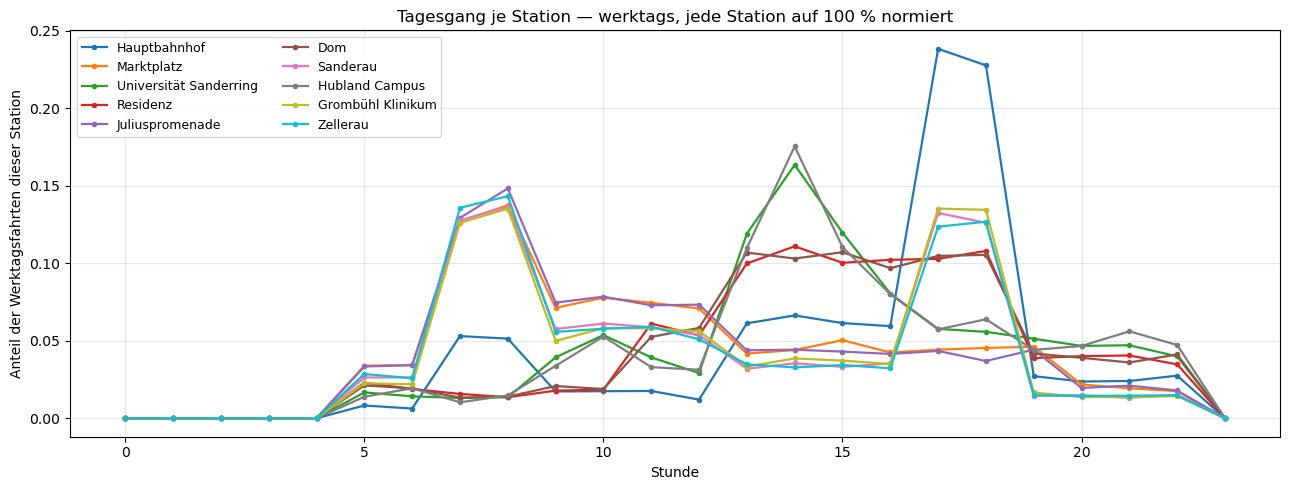

In [4]:
werktags = echte[~echte.ist_frei]
tagesgang = werktags.pivot_table(index="start_station_id", columns="stunde",
# nullen-sind-echt: Eine Station-Stunde ohne Fahrt hat null Fahrten.
                                 values="ausleihe_id", aggfunc="count").fillna(0)
# Zwischen 23 und 5 Uhr gibt es in den Daten keine Fahrt, die Stunden fehlen
# deshalb ganz. Das ist eine Aussage ueber die NACHFRAGE, nicht ueber die
# Verfuegbarkeit - ausleihen kann man rund um die Uhr, es tut nur niemand.
# Wir fuellen die Stunden ausdruecklich mit Null auf: ein Merkmalsvektor muss
# fuer jede Station dieselbe Laenge haben, und "keine Fahrten um 3 Uhr" ist
# eine Information, kein Loch.
tagesgang = tagesgang.reindex(columns=range(24), fill_value=0)
tagesgang = tagesgang.div(tagesgang.sum(axis=1), axis=0)      # je Station auf 1 normiert
print(f"Stunden mit Fahrten: {int((tagesgang.sum() > 0).sum())} von 24")
namen = stationen.set_index("station_id").name

plt.figure(figsize=(13, 5))
for sid in tagesgang.index:
    plt.plot(tagesgang.columns, tagesgang.loc[sid], marker=".", lw=1.6, label=namen[sid])
plt.xlabel("Stunde"); plt.ylabel("Anteil der Werktagsfahrten dieser Station")
plt.title("Tagesgang je Station — werktags, jede Station auf 100 % normiert")
plt.legend(ncol=2, fontsize=9); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Das Bild beantwortet die Frage:** Es gibt mindestens drei erkennbar verschiedene
Formen — scharfe Doppelspitzen morgens und abends, ein breiter Vormittagsberg, und flache
Nachmittagskurven. Ein Clustering hat also Substanz.

> **Warum wir normieren:** Ohne die Normierung würde der Hauptbahnhof alle anderen
> überragen, und das Clustering würde vor allem **Größe** gruppieren statt **Form**.
> Wir wollen aber wissen, *wann* eine Station genutzt wird, nicht *wieviel*. Das ist eine
> inhaltliche Entscheidung, die in Phase 3 gehört — hier sieht man, warum.

---

1. Business · 2. Data · **3. Data** · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 3 von 6 — Data Preparation

> **Leitfrage:** Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?
>
> **In diesem Notebook heißt das:** A) Aus Fahrten wird ein Tagesgang je Station. B) Aus Fahrten wird ein RFM-Profil je Kunde. Beides ist Aggregation — und beides braucht Standardisierung.

### 3.A Merkmale je Station

Wir geben jeder Station **26 Zahlen** mit: 24 für den normierten Tagesgang, dazu den
Wochenendanteil und die mittlere Fahrtdauer.

In [5]:
tagesgang.columns = [f"stunde_{h:02d}" for h in tagesgang.columns]
echte["dauer_min"] = (echte.endzeit - echte.startzeit).dt.total_seconds() / 60

zusatz = echte.groupby("start_station_id").agg(
    wochenendanteil=("ist_frei", "mean"),
    dauer_median=("dauer_min", "median"),
    fahrten_gesamt=("ausleihe_id", "size"),
)
S = tagesgang.join(zusatz)
S.index = [namen[i] for i in S.index]
print(S[["wochenendanteil", "dauer_median", "fahrten_gesamt"]].round(2).to_string())

                        wochenendanteil  dauer_median  fahrten_gesamt
Hauptbahnhof                       0.23          12.0            7897
Marktplatz                         0.26          12.0           12175
Universität Sanderring             0.18          11.0            5753
Residenz                           0.58          11.0           11257
Juliuspromenade                    0.25          12.0           13108
Dom                                0.59          11.0           11310
Sanderau                           0.14          23.0           12289
Hubland Campus                     0.18          26.0            5795
Grombühl Klinikum                  0.14          13.0           12485
Zellerau                           0.14          18.0           12332


Schon diese drei Spalten trennen sichtbar: Der Wochenendanteil reicht von rund 11 % bis
knapp 50 %. Das wird gleich ein starkes Merkmal sein.

### Standardisieren — und warum das hier zwingend ist

In [6]:
from sklearn.preprocessing import StandardScaler

merkmale_station = [s for s in S.columns if s != "fahrten_gesamt"]
print("Größenordnungen VOR der Standardisierung:")
print(S[merkmale_station].describe().loc[["mean", "std"]].round(3).T.head(6).to_string())

S_skaliert = StandardScaler().fit_transform(S[merkmale_station])

print(f"\nNach der Standardisierung: Mittelwert {S_skaliert.mean():.2f}, "
      f"Streuung {S_skaliert.std():.2f}")

Größenordnungen VOR der Standardisierung:
            mean    std
stunde_00  0.000  0.000
stunde_01  0.000  0.000
stunde_02  0.000  0.000
stunde_03  0.000  0.000
stunde_04  0.000  0.000
stunde_05  0.023  0.008

Nach der Standardisierung: Mittelwert 0.00, Streuung 0.88


> **Warum das nicht optional ist.** k-Means misst Abstände. Der Wochenendanteil liegt
> zwischen 0 und 0,5, die mittlere Fahrtdauer zwischen 10 und 25 — ohne Standardisierung
> wäre die Fahrtdauer allein durch ihre **Maßeinheit** rund fünfzigmal wichtiger als der
> Wochenendanteil. Das Verfahren würde dann nicht das Wichtigste gruppieren, sondern das
> Großzahligste.

### 3.B Merkmale je Kunde: das RFM-Modell

Für die Kundschaft nehmen wir ein Verfahren, das im Handel seit Jahrzehnten Standard ist
und ohne jede Statistikkenntnis erklärbar bleibt — **RFM**:

| | steht für | hier gemessen als |
|---|---|---|
| **R**ecency | Wie lange ist der letzte Kauf her? | Tage seit der letzten Fahrt |
| **F**requency | Wie oft wird gekauft? | Fahrten in den letzten 365 Tagen |
| **M**onetary | Wieviel wird ausgegeben? | Entgelt in den letzten 365 Tagen |

In [7]:
# EIN CUTOFF, UND ER LIEGT HINTER DEN DATEN - NICHT MITTENDRIN.
#
# Eine fruehere Fassung setzte den Stichtag auf .normalize() des letzten
# Fahrtbeginns: 24.08.2026 00:00. Das Fenster hatte aber keine obere
# Grenze und nahm die 77 Fahrten desselben Tages bis 22:57 Uhr mit. Der
# Export behauptete damit einen Informationsstand um Mitternacht und
# rechnete mit Daten aus dessen Zukunft.
#
# Die Stabilitaetspruefung schnitt umgekehrt bei "<= tag" ab und liess
# genau diese 77 Fahrten weg. RFM, Stabilitaet und Export standen damit
# auf drei verschiedenen Populationen.
DATENSTAND = echte.startzeit.max()
merke("datenstand", DATENSTAND.strftime("%d.%m.%Y"))
CUTOFF = DATENSTAND.normalize() + pd.Timedelta(days=1)
stichtag = CUTOFF                      # ein Name, ein Zeitpunkt
FENSTER_TAGE = 365
# ABGESCHLOSSEN vor dem Cutoff, nicht nur begonnen. Entgelt und Dauer
# stehen erst mit der Rueckgabe fest; eine Fahrt, die vorher beginnt und
# danach endet, brächte Information aus der Zukunft in den Schnappschuss.
# Am frueheren Cutoff gibt es genau so einen Fall.
fenster = echte[(echte.startzeit > CUTOFF - pd.Timedelta(days=FENSTER_TAGE))
                & (echte.endzeit < CUTOFF)]
print(f"Datenstand:  letzte Fahrt {DATENSTAND:%d.%m.%Y %H:%M} Uhr")
print(f"Cutoff:      {CUTOFF:%d.%m.%Y %H:%M} Uhr - alles davor zaehlt, nichts danach")
print(f"Fenster:     die {FENSTER_TAGE} Tage davor\n")

rfm = fenster.groupby("kunde_id").agg(
    letzte_fahrt=("startzeit", "max"),
    frequenz=("ausleihe_id", "size"),
    umsatz=("entgelt_eur", "sum"),
)
rfm["recency"] = (stichtag - rfm.letzte_fahrt).dt.days.clip(lower=0)
rfm = rfm.join(kunden.set_index("kunde_id")[["tarif_code", "geburtsjahr", "registriert_am"]])

print(f"Stichtag: {stichtag.date()}, Fenster: letzte 365 Tage")

# UNTERSCHIEDLICHE BEOBACHTUNGSDAUER
# "Fahrten je Jahr" heisst nur dann dasselbe, wenn alle ein Jahr lang
# beobachtet wurden. Wer sich vor drei Monaten angemeldet hat, kann gar
# kein volles Jahr voll bekommen - und landet zwangslaeufig weiter unten.
neu_dabei = kunden.set_index("kunde_id").registriert_am > stichtag - pd.Timedelta(days=365)
print(f"Davon erst im Fenster angemeldet: {int(neu_dabei.reindex(rfm.index).fillna(False).sum())} "
      f"- fuer sie ist 'je Jahr' eine Untertreibung.")
merke("n_rfm", len(rfm))
print(f"Kundschaft mit mindestens einer Fahrt darin: {len(rfm)} von {len(kunden)}")
print(f"ohne jede Fahrt im Fenster: {len(kunden) - len(rfm)} — die betrachten wir gleich gesondert\n")
print(rfm[["recency", "frequenz", "umsatz"]].describe().round(1).to_string())

Datenstand:  letzte Fahrt 24.08.2026 21:56 Uhr
Cutoff:      25.08.2026 00:00 Uhr - alles davor zaehlt, nichts danach
Fenster:     die 365 Tage davor

Stichtag: 2026-08-25, Fenster: letzte 365 Tage
Davon erst im Fenster angemeldet: 510 - fuer sie ist 'je Jahr' eine Untertreibung.
Kundschaft mit mindestens einer Fahrt darin: 2271 von 3200
ohne jede Fahrt im Fenster: 929 — die betrachten wir gleich gesondert

       recency  frequenz  umsatz
count   2271.0    2271.0  2271.0
mean      54.9      10.6    22.1
std       80.9      10.3    26.9
min        0.0       1.0     0.1
25%       10.0       3.0     5.0
50%       24.0       7.0    12.6
75%       55.0      15.0    29.3
max      363.0      61.0   247.8


### Die schiefe Verteilung — und was man dagegen tut

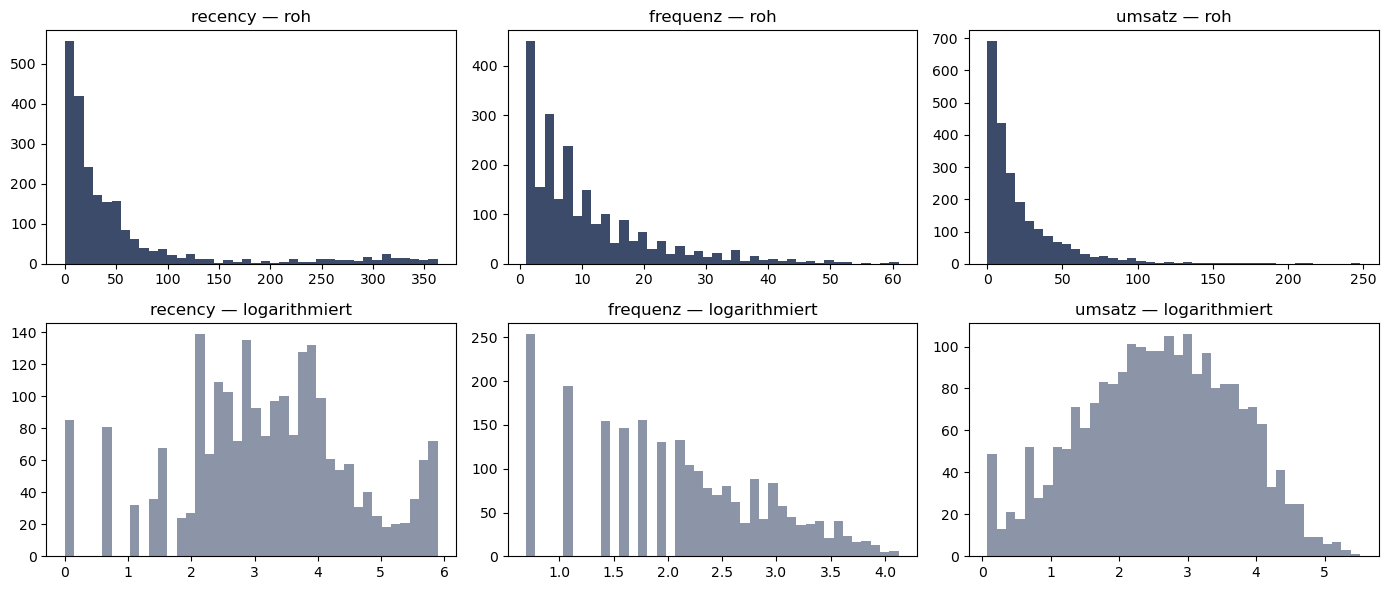

Frequenz und Umsatz gehen logarithmiert ein, Recency roh.


In [8]:
fig, achsen = plt.subplots(2, 3, figsize=(14, 6))
for spalte, achse in zip(["recency", "frequenz", "umsatz"], achsen[0]):
    achse.hist(rfm[spalte], bins=40, color="#3d4b6b")
    achse.set_title(f"{spalte} — roh")
for spalte, achse in zip(["recency", "frequenz", "umsatz"], achsen[1]):
    achse.hist(np.log1p(rfm[spalte]), bins=40, color="#8c95a8")
    achse.set_title(f"{spalte} — logarithmiert")
plt.tight_layout(); plt.show()

R = rfm[["recency", "frequenz", "umsatz"]].copy()
R["frequenz"] = np.log1p(R.frequenz)
R["umsatz"] = np.log1p(R.umsatz)
R_skaliert = StandardScaler().fit_transform(R)
print("Frequenz und Umsatz gehen logarithmiert ein, Recency roh.")

**Frequenz und Umsatz sind stark rechtsschief**: sehr viele kleine Werte, wenige sehr
große. k-Means würde sich an den wenigen Extremfällen festbeißen und aus ihnen eigene
Cluster machen — und die restlichen 95 % in einen Topf werfen.

Der Logarithmus zieht den Ausläufer zusammen (untere Reihe) und macht aus „hundertmal so
viel“ ein handhabbares „doppelt so weit weg“. **Recency lassen wir roh**, weil sie ohnehin
gleichmäßiger verteilt ist und ihre Einheit — Tage — anschaulich bleibt.

---

1. Business · 2. Data · 3. Data · **4. Modeling** · 5. Evaluation · 6. Deployment

# Phase 4 von 6 — Modeling

> **Leitfrage:** Welches Verfahren, welche Einstellungen, wie geprüft?
>
> **In diesem Notebook heißt das:** k-Means für beide Aufgaben. Die eigentliche Frage lautet: **wie viele Gruppen?**

### 4.1 Wie k-Means arbeitet — in vier Sätzen

1. Wirf *k* Punkte zufällig in den Merkmalsraum („Zentren“).
2. Ordne jedes Objekt dem nächstgelegenen Zentrum zu.
3. Verschiebe jedes Zentrum in die Mitte der ihm zugeordneten Objekte.
4. Wiederhole 2 und 3, bis sich nichts mehr bewegt.

Mehr ist es nicht. Die Schwierigkeit liegt nicht im Verfahren, sondern in der Frage, die
es **nicht** beantwortet: wie groß *k* sein soll.

### 4.2 Die Ellenbogenmethode und der Silhouettenwert

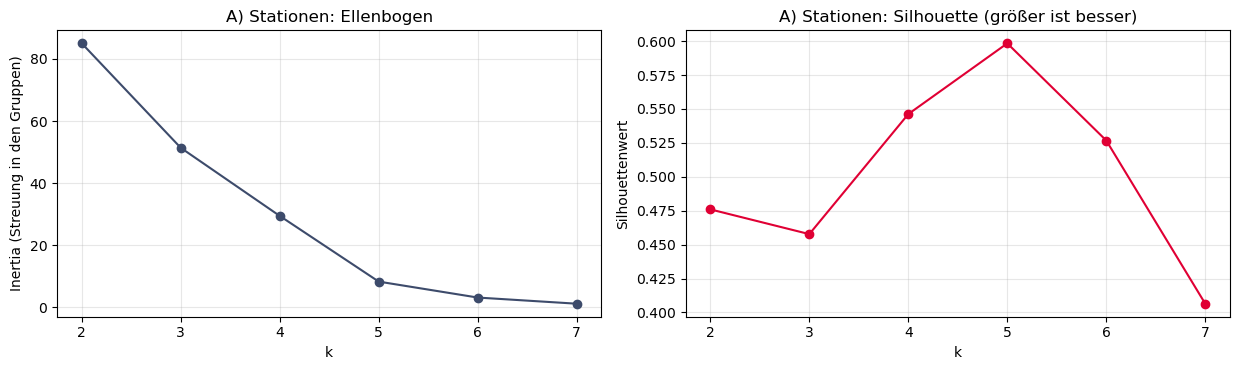

 k  Inertia  Silhouette
 2     85.0       0.476
 3     51.4       0.458
 4     29.5       0.546
 5      8.3       0.598
 6      3.2       0.527
 7      1.2       0.406


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def k_suchen(X, titel, ks=range(2, 8)):
    inertia, silhouette = [], []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=25, random_state=42).fit(X)
        inertia.append(km.inertia_)
        silhouette.append(silhouette_score(X, km.labels_))
    fig, achsen = plt.subplots(1, 2, figsize=(12.5, 3.8))
    achsen[0].plot(list(ks), inertia, marker="o", color="#3d4b6b")
    achsen[0].set_xlabel("k"); achsen[0].set_ylabel("Inertia (Streuung in den Gruppen)")
    achsen[0].set_title(f"{titel}: Ellenbogen"); achsen[0].grid(alpha=.3)
    achsen[1].plot(list(ks), silhouette, marker="o", color="#e00034")
    achsen[1].set_xlabel("k"); achsen[1].set_ylabel("Silhouettenwert")
    achsen[1].set_title(f"{titel}: Silhouette (größer ist besser)"); achsen[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()
    tafel = pd.DataFrame({"k": list(ks), "Inertia": np.round(inertia, 1),
                          "Silhouette": np.round(silhouette, 3)})
    # Die Kennzahlen wandern in den Fliesstext, statt dort getippt zu werden.
    kurz = "stationen" if titel.startswith("A") else "kunden"
    best = tafel.loc[tafel.Silhouette.idxmax()]
    merke(f"sil_{kurz}_bestes_k", int(best.k))
    merke(f"sil_{kurz}_bestwert", float(best.Silhouette))
    merke(f"sil_{kurz}_k4", float(tafel.loc[tafel.k == 4, "Silhouette"].iloc[0]))
    return tafel

print(k_suchen(S_skaliert, "A) Stationen").to_string(index=False))

**Die Inertia fällt immer** — bei *k* = 10 wäre sie null, denn dann ist jede Station ihr
eigenes Cluster. Gesucht ist der **Knick**: die Stelle, ab der zusätzliche Gruppen kaum
noch Streuung wegnehmen.

Der Silhouettenwert misst etwas anderes: Wie viel näher liegt ein Objekt bei seiner
eigenen Gruppe als bei der nächstbesten? Werte über 0,5 gelten als deutliche Struktur.

> **Beide Maße sind Hinweise, keine Entscheidungen.** Die Entscheidung fällt in Phase 5
> und stützt sich auf die Kriterien aus Phase 1 — vor allem auf die Benennbarkeit.


EMPFINDLICHKEIT gegenueber der Blockgewichtung (k = 4):
     Gewicht Stundenblock   ARI zur Notebookloesung
                     50%                    0.280
                     70%                    0.400
                     90%                    0.400
                     92%                    1.000  <- entspricht der Spaltenzahl

   Bei Gleichgewichtung der beiden Bloecke betraegt der ARI zur
   Notebookloesung nur 0.28 - das ist eine ANDERE Einteilung.
   Das beweist nicht, dass sie besser ist. Es zeigt, dass die Loesung
   an einer Entscheidung haengt, die bisher niemand getroffen hat:
   Der Stundenblock wiegt schwer, weil er 24 Spalten hat, nicht weil
   jemand ihn fuer das Wesentliche haelt.
Ergebnis mit k = 4:

  Cluster 0: Sanderau, Grombühl Klinikum, Zellerau
  Cluster 1: Universität Sanderring, Residenz, Dom, Hubland Campus
  Cluster 2: Hauptbahnhof
  Cluster 3: Marktplatz, Juliuspromenade


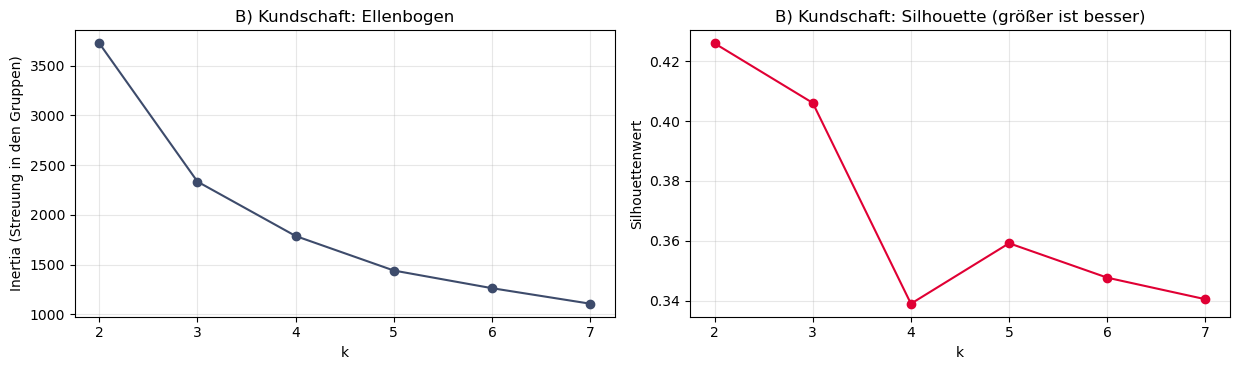

 k  Inertia  Silhouette
 2   3724.7       0.426
 3   2334.7       0.406
 4   1788.3       0.339
 5   1441.4       0.359
 6   1264.0       0.348
 7   1108.1       0.340


In [10]:
K_STATIONEN = 4
km_stationen = KMeans(n_clusters=K_STATIONEN, n_init=25, random_state=42).fit(S_skaliert)

# ─── WIE STARK HAENGT DIE LOESUNG AN DER GEWICHTUNG? ────────────────
# Jedes der 26 Merkmale wird EINZELN standardisiert. Damit wiegt der Block
# aus 24 Stundenwerten zusammen zwoelfmal so schwer wie Wochenendanteil und
# Mediandauer zusammen - eine Entscheidung, die niemand getroffen hat, sie
# ergibt sich aus der Anzahl der Spalten.
from sklearn.metrics import adjusted_rand_score
_stunden = [i for i, s in enumerate(merkmale_station) if s.startswith("stunde_")]
_andere = [i for i in range(len(merkmale_station)) if i not in _stunden]

def _mit_gewicht(anteil_stunden):
    # Jeden Block auf seine eigene Summe normieren, dann gewichten: So
    # entscheidet die gewuenschte Bedeutung, nicht die Spaltenzahl.
    x = S_skaliert.copy()
    x[:, _stunden] *= np.sqrt(anteil_stunden / len(_stunden))
    x[:, _andere] *= np.sqrt((1 - anteil_stunden) / len(_andere))
    return KMeans(n_clusters=4, n_init=25, random_state=42).fit_predict(x)

_grund = KMeans(n_clusters=4, n_init=25, random_state=42).fit_predict(S_skaliert)
print("\nEMPFINDLICHKEIT gegenueber der Blockgewichtung (k = 4):")
print(f"   {'Gewicht Stundenblock':>22s}{'ARI zur Notebookloesung':>26s}")
for _a in (0.5, 0.7, 0.9, len(_stunden) / len(merkmale_station)):
    _ari = adjusted_rand_score(_grund, _mit_gewicht(_a))
    _marke = "  <- entspricht der Spaltenzahl" if _a > 0.9 else ""
    print(f"   {_a:>21.0%}{_ari:>25.3f}{_marke}")
merke("gewicht_ari_halb", adjusted_rand_score(_grund, _mit_gewicht(0.5)))
_ari_halb = adjusted_rand_score(_grund, _mit_gewicht(0.5))
print()
if _ari_halb < 0.7:
    print(f"   Bei Gleichgewichtung der beiden Bloecke betraegt der ARI zur")
    print(f"   Notebookloesung nur {_ari_halb:.2f} - das ist eine ANDERE Einteilung.")
    print("   Das beweist nicht, dass sie besser ist. Es zeigt, dass die Loesung")
    print("   an einer Entscheidung haengt, die bisher niemand getroffen hat:")
    print("   Der Stundenblock wiegt schwer, weil er 24 Spalten hat, nicht weil")
    print("   jemand ihn fuer das Wesentliche haelt.")
else:
    print(f"   Auch bei Gleichgewichtung bleibt die Einteilung weitgehend")
    print(f"   dieselbe (ARI {_ari_halb:.2f}) - die Loesung haengt hier nicht an")
    print("   der Blockgewichtung. Das ist ein guenstiger Befund, kein")
    print("   garantierter: Bei anderen Merkmalen kann es anders liegen.")
S["cluster"] = km_stationen.labels_

print(f"Ergebnis mit k = {K_STATIONEN}:\n")
for c in sorted(S.cluster.unique()):
    mitglieder = list(S.index[S.cluster == c])
    print(f"  Cluster {c}: {', '.join(mitglieder)}")

print(k_suchen(R_skaliert, "B) Kundschaft").to_string(index=False))

In [11]:
K_KUNDEN = 4
km_kunden = KMeans(n_clusters=K_KUNDEN, n_init=25, random_state=42).fit(R_skaliert)
rfm["cluster"] = km_kunden.labels_

profil = rfm.groupby("cluster").agg(
    kunden=("frequenz", "size"),
    recency_tage=("recency", "mean"),
    fahrten_fenster=("frequenz", "mean"),
    umsatz_fenster=("umsatz", "mean"),
).round(1)
# Umsatz JE FAHRT - die Groesse, um die es gleich geht. Ohne sie liest man
# die Tabelle falsch: Das fahrtstaerkste Segment hat nicht den geringsten
# Jahresumsatz, sondern den geringsten Umsatz je Fahrt.
profil["umsatz_je_fahrt"] = (profil.umsatz_fenster / profil.fahrten_fenster).round(2)
profil["anteil"] = (profil.kunden / profil.kunden.sum() * 100).round(1)
print(profil.to_string())

         kunden  recency_tage  fahrten_fenster  umsatz_fenster  umsatz_je_fahrt  anteil
cluster                                                                                
0           629          14.9             22.7            50.3             2.22    27.7
1           935          30.0              8.6            16.3             1.90    41.2
2           210         284.2              2.0             6.8             3.40     9.2
3           497          55.5              2.8             3.8             1.36    21.9


---

1. Business · 2. Data · 3. Data · 4. Modeling · **5. Evaluation** · 6. Deployment

# Phase 5 von 6 — Evaluation

> **Leitfrage:** Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?
>
> **In diesem Notebook heißt das:** Ohne Zielgröße gibt es keine Trefferquote. Es gibt aber die fünf Kriterien aus Phase 1 — und die sind streng genug.

### 5.A Stationen: ergeben die Gruppen fachlich Sinn?

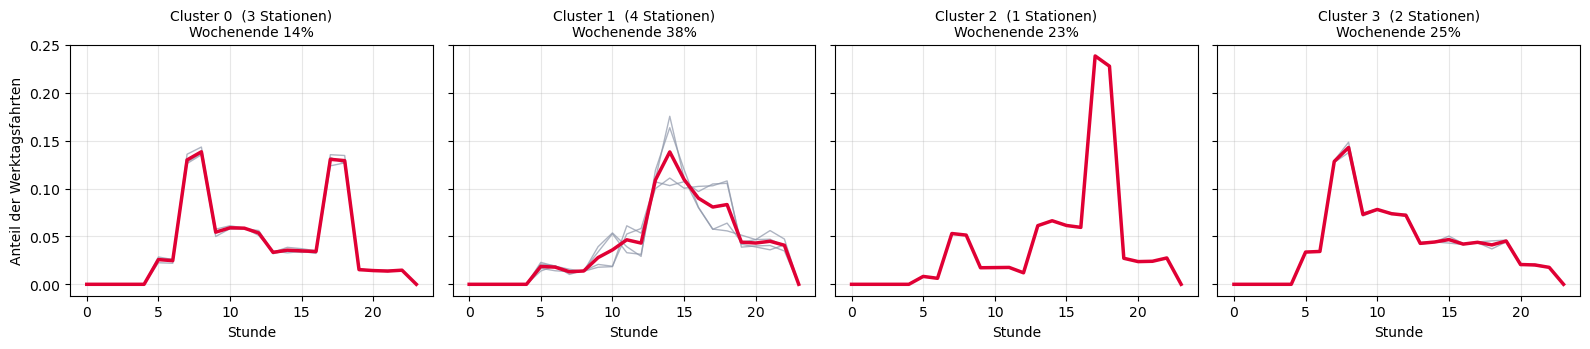

Cluster 0: Sanderau, Grombühl Klinikum, Zellerau                          Spitze  8 Uhr, Wochenende 14%, Dauer 18 Min
Cluster 1: Universität Sanderring, Residenz, Dom, Hubland Campus          Spitze 14 Uhr, Wochenende 38%, Dauer 15 Min
Cluster 2: Hauptbahnhof                                                   Spitze 17 Uhr, Wochenende 23%, Dauer 12 Min
Cluster 3: Marktplatz, Juliuspromenade                                    Spitze  8 Uhr, Wochenende 25%, Dauer 12 Min


In [12]:
fig, achsen = plt.subplots(1, K_STATIONEN, figsize=(16, 3.6), sharey=True)
stundenspalten = [s for s in S.columns if s.startswith("stunde_")]
for c, achse in zip(sorted(S.cluster.unique()), achsen):
    gruppe = S[S.cluster == c]
    for name in gruppe.index:
        achse.plot(range(24), gruppe.loc[name, stundenspalten].values,
                   color="#8c95a8", lw=1, alpha=.7)
    achse.plot(range(24), gruppe[stundenspalten].mean().values, color="#e00034", lw=2.5)
    achse.set_title(f"Cluster {c}  ({len(gruppe)} Stationen)\n"
                    f"Wochenende {gruppe.wochenendanteil.mean():.0%}", fontsize=10)
    achse.set_xlabel("Stunde"); achse.grid(alpha=.3)
achsen[0].set_ylabel("Anteil der Werktagsfahrten")
plt.tight_layout(); plt.show()

for c in sorted(S.cluster.unique()):
    g = S[S.cluster == c]
    # Die Stunde steht im SPALTENNAMEN, nicht im Index: Vor fuenf Uhr faehrt
    # niemand, also fehlen die ersten Spalten - ein Index waere um genau diese
    # Zahl verschoben und ergaebe Spitzen um drei Uhr morgens.
    spitze = int(g[stundenspalten].mean().idxmax().removeprefix("stunde_"))
    print(f"Cluster {c}: {', '.join(g.index):<62s} Spitze {spitze:>2d} Uhr, "
          f"Wochenende {g.wochenendanteil.mean():.0%}, Dauer {g.dauer_median.mean():.0f} Min")

### Die Gruppen benennen — Kriterium 1 aus Phase 1

Jetzt kommt der Schritt, den kein Algorithmus abnimmt. Die Zahlen liefern Gruppen; **die
Namen liefert der Verstand.**

Die Zeile über jedem Cluster nennt drei Größen, und jede beantwortet eine andere Frage:

| Größe | Frage | Was ein hoher Wert bedeutet |
|---|---|---|
| **Spitzenstunde** | Wann wird abgefahren? | früh = von zuhause weg, spät = zurück oder Ankunft |
| **Wochenendanteil** | Ist es Pflicht oder Freizeit? | hoch = Ausflug, niedrig = Arbeit oder Studium |
| **Mediandauer** | Wie weit? | lang = Weg über die Stadt, kurz = innerstädtischer Sprung |

Erst die **Kombination** trägt einen Namen. Eine frühe Spitze allein sagt nichts: Sie
steht am Wohnort für den Weg zur Arbeit und am Bahnhof für den Anschluss an den Zug. Mit
niedrigem Wochenendanteil und langer Dauer wird daraus eine **Wohnstation**; mit hohem
Wochenendanteil und kurzer Dauer eine Freizeitlage.

**Lesen Sie die gedruckte Zeile, nicht diesen Absatz.** Die Namen, die das Notebook
vergibt, stehen in der Tabelle der nächsten Zelle — sie werden aus genau diesen drei
Größen abgeleitet und ändern sich mit ihnen. Ein Fließtext, der die Gruppen aufzählt,
wäre nach der nächsten Datenlieferung falsch, ohne dass es jemand merkt.

> **Eine Gruppe ist auffällig klein.** Bei zehn Stationen und k = 4 besteht ein Cluster
> nur aus einer einzigen Station. Das ist kein Typ, sondern ein Sonderfall — und
> Sonderfälle behandelt man einzeln. Rechnen Sie damit, dass diese Gruppe bei der
> nächsten Datenlieferung anders aussieht; zehn Beobachtungen tragen keine Typologie,
> sie tragen eine Arbeitshypothese.

**Kriterien 1 bis 3 aus Phase 1 sind damit erfüllt:** Jede Gruppe ist benennbar, jede
bekommt in Phase 6 eine eigene Regel, und keine ist zu klein. Kriterium 2 wird dort
außerdem maschinell geprüft — **vier Gruppen müssen vier verschiedene Prüfungshypothesen
ergeben.** Eine frühere Fassung dieses Notebooks hat genau daran gescheitert, ohne dass
es auffiel.

### Kriterien 4 und 5: Stabilität — gemessen, nicht behauptet

`n_init=25` ist **keine** Stabilitätsprüfung. Es rechnet 25 Startpunkte durch und nimmt
den mit der geringsten Streuung — das ist Qualitätssicherung innerhalb eines Laufs, nicht
die Frage, ob ein anderer Zufallsstart dieselben Gruppen liefert.

Die Frage lässt sich beantworten: Man clustert mehrfach mit verschiedenen Startwerten und
vergleicht die Einteilungen mit dem **adjustierten Rand-Index**. Er ist 1,0 bei
identischer Gruppierung und 0 bei zufälliger Übereinstimmung.

In [13]:
from sklearn.metrics import adjusted_rand_score

def stabilitaet(daten, k, name):
    """Liefern andere Zufallsstarts dieselbe Einteilung?"""
    grund = KMeans(n_clusters=k, n_init=25, random_state=42).fit_predict(daten)
    werte = []
    for seed in (0, 1, 7, 99, 2024):
        andere = KMeans(n_clusters=k, n_init=25, random_state=seed).fit_predict(daten)
        werte.append(adjusted_rand_score(grund, andere))
    print(f"{name:14s} ARI über fünf Startwerte: "
          f"{min(werte):.3f} bis {max(werte):.3f}   "
          f"{'stabil' if min(werte) > 0.99 else 'nur annähernd stabil'}")
    return min(werte)

s_stab = merke("ari_stationen", stabilitaet(S_skaliert, K_STATIONEN, "Stationen"))
k_stab = merke("ari_kunden", stabilitaet(R_skaliert, K_KUNDEN, "Kundschaft"))

Stationen      ARI über fünf Startwerte: 1.000 bis 1.000   stabil


Kundschaft     ARI über fünf Startwerte: 1.000 bis 1.000   stabil


Der Startwert ist aber nicht die Frage, die im Betrieb zählt. Dort wird **nicht mit einem
anderen Zufallsstart** neu gerechnet, sondern **ein Quartal später mit neuen Daten**. Ob
ein Kunde dann noch im selben Segment liegt, entscheidet darüber, ob man ihm überhaupt
eine Kampagne schicken kann.

Das lässt sich messen: dieselbe Rechnung, verschoben um 90 Tage.

In [14]:
from scipy.optimize import linear_sum_assignment

# DIE SCHWELLEN STEHEN HIER - VOR IHRER PRUEFUNG.
#
# Sie sind an den Clusterprofilen abgelesen; das Clustering war die
# Erkundung. Angewendet werden sie auf jede einzelne Kundenzeile, und
# genau diese Regeln gehen in Phase 6 in den Export.
SCHWELLE_RECENCY = 150
SCHWELLE_FREQUENZ = 12
SCHWELLE_UMSATZ = 30

# DIE NAMEN DUERFEN NUR SAGEN, WAS DIE REGEL PRUEFT.
#
# Die Schwellen kennen Recency, Frequenz und Umsatz - den Tarif nicht.
# Frueher hiessen zwei Segmente "Vielfahrer mit Freiminuten" und
# "Umsatztraeger im Basistarif". Gemessen: 82 der 520 Vielfahrer (15,8 %)
# haben BASIS, also gar keine Freiminuten. Der Name behauptete etwas, das
# die Regel nicht geprueft hat - und fuer jeden sechsten war er falsch.
#
# Der Tarif steht als eigene Spalte im Export. Massnahmen gehoeren aus der
# KOMBINATION Segment x Tarif abgeleitet, nicht aus einem Namen.
def segment_benennen(zeile, vorheriges=None, rand=0.0):
    """Das Segment einer Zeile - mit optionaler HYSTERESE.

    Ohne Hysterese wechselt jede Person das Segment, sobald sie eine
    Schwelle um einen einzigen Punkt ueberquert. Bei Schwellen mitten in
    der Verteilung erzeugt das Wechsel, die keine Verhaltensaenderung
    sind, sondern Messrauschen - und eine Kampagne, die jedem Quartal eine
    andere Ansprache schickt, wirkt beliebig.

    Die Hysterese ist die uebliche Antwort darauf: Wer ein Segment schon
    hat, behaelt es, solange er die um `rand` aufgeweitete Schwelle nicht
    verlaesst. Das ist kein Trick, um eine Kennzahl zu schoenen - es ist
    dieselbe Logik wie beim Thermostat, der nicht bei jedem Zehntelgrad
    schaltet.
    """
    def hart(r, f, u):
        if r > SCHWELLE_RECENCY:
            return "Eingeschlafen"
        if f > SCHWELLE_FREQUENZ:
            return "Vielfahrer"
        if u > SCHWELLE_UMSATZ:
            return "Umsatzträger"
        return "Gelegenheitsnutzer"

    jetzt = hart(zeile.recency, zeile.frequenz, zeile.umsatz)
    if not rand or vorheriges is None or vorheriges == jetzt:
        return jetzt
    # Mit aufgeweiteten Schwellen noch im alten Segment? Dann dabei bleiben.
    weich = hart(zeile.recency * (1 - rand),
                 zeile.frequenz * (1 + rand),
                 zeile.umsatz * (1 + rand))
    weich_2 = hart(zeile.recency * (1 + rand),
                   zeile.frequenz * (1 - rand),
                   zeile.umsatz * (1 - rand))
    return vorheriges if vorheriges in (weich, weich_2) else jetzt


def rfm_zum_cutoff(cut):
    """Dieselbe RFM-Rechnung wie oben, nur zu einem anderen Zeitpunkt.
    Dieselbe Fenstergrenze, dieselbe Ausschlussregel - sonst vergliche
    man zwei verschiedene Populationen."""
    f = echte[(echte.startzeit > cut - pd.Timedelta(days=FENSTER_TAGE))
              & (echte.endzeit < cut)]
    return f.groupby("kunde_id").agg(
        recency=("startzeit", lambda s: (cut - s.max()).days),
        frequenz=("ausleihe_id", "size"), umsatz=("entgelt_eur", "sum"))

def regel_segmente_zum(cut, vorher=None):
    """Was das AUSGELIEFERTE Verfahren zu diesem Zeitpunkt gesagt haette.

    `vorher` traegt die Segmente des Vorquartals herein - nur so kann die
    Hysterese wirken. Ohne sie ist jede Auswertung gedaechtnislos, und die
    Stabilitaet misst dann die Schwellenlage, nicht das Verhalten.
    """
    z = rfm_zum_cutoff(cut)
    if vorher is None:
        return z.apply(segment_benennen, axis=1)
    return z.apply(lambda r: segment_benennen(
        r, vorher.get(r.name), HYSTERESE), axis=1)

def cluster_segmente_zum(cut):
    """Was ein NEU gerechnetes k-Means gesagt haette - Modelldiagnose."""
    r = rfm_zum_cutoff(cut)
    R = r.copy()
    R["frequenz"] = np.log1p(R.frequenz)
    R["umsatz"] = np.log1p(R.umsatz)
    labels = KMeans(n_clusters=K_KUNDEN, n_init=25, random_state=42).fit_predict(
        StandardScaler().fit_transform(R))
    return pd.Series(labels, index=r.index)

VORQUARTAL = CUTOFF - pd.Timedelta(days=90)

# ---------------------------------------------------------------------
# (1) DAS GATE: die Stabilitaet DES AUSGELIEFERTEN PRODUKTS.
#
# Eine fruehere Fassung mass hier die Stabilitaet eines jeweils NEU
# gerechneten k-Means - und band den Export daran. Ausgeliefert werden
# aber feste Schwellen. Das Gate bewertete also ein Verfahren, das
# niemand bekommt.
#
# Bei festen Segmentnamen braucht es kein Labelmatching: Die Namen sind
# an beiden Stichtagen dieselben, ein Vergleich genuegt.
# ---------------------------------------------------------------------
# Die Reihenfolge ist wichtig: erst das Vorquartal ohne Gedaechtnis, dann
# das aktuelle MIT dem Vorquartal als Ausgangslage - so, wie es im Betrieb
# liefe. Andersherum gerechnet waere die Hysterese wirkungslos.
regel_vor = regel_segmente_zum(VORQUARTAL)
regel_heute = regel_segmente_zum(CUTOFF, vorher=regel_vor)
gemeinsam = regel_heute.index.intersection(regel_vor.index)
wechselquote = float((regel_heute[gemeinsam] != regel_vor[gemeinsam]).mean())

# ---------------------------------------------------------------------
# (0) UND DIE STATIONEN? Auch dort war "stabil" bisher nur eine Aussage
#     ueber Zufallsstartwerte - also ueber die Rechnung, nicht ueber die
#     Zeit. Dieselbe Frage, dieselbe Methode.
# ---------------------------------------------------------------------
def stationsmerkmale(f):
    """Die 26 Zahlen je Station - EINE Definition fuer alle Verwendungen.

    Der Hauptlauf nahm 24 WERKTAGSstunden plus Wochenendanteil plus
    Mediandauer; die Stabilitaetspruefung nahm 24 Stunden ueber alle Tage
    und liess die beiden anderen weg. Sie prueft dann eine verwandte, aber
    nicht dieselbe Repraesentation - und ein guenstiges Ergebnis sagt
    nichts ueber das Modell, das wirklich laeuft.
    """
    f = f.copy()
    f["stunde"] = f.startzeit.dt.hour
    f["dauer_min"] = (f.endzeit - f.startzeit).dt.total_seconds() / 60
    _werktags = f[~f.ist_frei]
    g = (_werktags.groupby(["start_station_id", "stunde"]).size()
         .unstack(fill_value=0).reindex(columns=range(24), fill_value=0))
    g = g.div(g.sum(axis=1).clip(lower=1), axis=0)
    g.columns = [f"stunde_{h:02d}" for h in g.columns]
    z = f.groupby("start_station_id").agg(
        wochenendanteil=("ist_frei", "mean"),
        dauer_median=("dauer_min", "median"))
    # nullen-sind-echt: Eine Station ohne Werktagsfahrt in einer Stunde hat
    # dort null Fahrten. Die Spalte fehlt nur, weil niemand gefahren ist.
    return g.join(z).fillna(0.0)


def stationstypen_zum(cut):
    f = echte[(echte.startzeit > cut - pd.Timedelta(days=FENSTER_TAGE))
              & (echte.endzeit < cut)]
    g = stationsmerkmale(f)
    return pd.Series(
        KMeans(n_clusters=K_STATIONEN, n_init=25, random_state=42)
        .fit_predict(StandardScaler().fit_transform(g)), index=g.index)

st_heute = stationstypen_zum(CUTOFF)
st_vor = stationstypen_zum(CUTOFF - pd.Timedelta(days=90))
st_gem = st_heute.index.intersection(st_vor.index)
print("(0) STATIONEN ueber die ZEIT (nicht nur ueber Startwerte)\n")
print(f"    ARI zwischen den beiden Stichtagen: "
      f"{adjusted_rand_score(st_vor[st_gem], st_heute[st_gem]):.3f}\n")

print("(1a) DIE VIER RFM-REGELN - feste Schwellen, beide Stichtage\n")
print(f"     In beiden Fenstern aktiv: {len(gemeinsam)} Kundinnen und Kunden")
merke("gate_rfm", wechselquote)
print(f"     Segmentwechsel binnen 90 Tagen: {wechselquote:.1%}")

# ---------------------------------------------------------------------
# (1b) DIE VOLLSTAENDIGE AUSLIEFERUNG - sieben Lebenszyklussegmente.
#
# Der Export enthaelt mehr als die vier RFM-Segmente: "Frueher aktiv,
# jetzt inaktiv" und "Neu, noch keine Erstfahrt" kommen dazu, "Nie
# aktiviert" wird analysiert und ausgeschlossen. Ein Gate, das nur die
# vier misst, laesst genau die Uebergaenge aus, die entscheiden, WER
# ueberhaupt angeschrieben wird - naemlich den Wechsel zwischen aktiv
# und inaktiv.
# ---------------------------------------------------------------------
def lebenszyklus_zum(cut, vorher=None, hysterese=None):
    """Die vollstaendige siebenstufige Logik zu einem Zeitpunkt.

    `hysterese` ist nur fuer die Sensitivitaetsrechnung da: Mit 0.0
    laeuft dieselbe Logik ohne Kantenglaettung. Im Betrieb gilt immer
    der Wert aus Phase 1.
    """
    h = HYSTERESE if hysterese is None else hysterese
    r = rfm_zum_cutoff(cut)
    seg = (r.apply(segment_benennen, axis=1) if vorher is None
           else r.apply(lambda z: segment_benennen(
               z, vorher.get(z.name), h), axis=1))
    gefahren_bis = set(echte.loc[echte.endzeit < cut, "kunde_id"])
    reg = pd.to_datetime(kunden.set_index("kunde_id").registriert_am)
    dabei = (cut - reg).dt.days
    # nur Kundschaft, die zu diesem Zeitpunkt schon registriert war
    registriert = dabei[dabei >= 0].index
    ergebnis = {}
    for kid in registriert:
        if kid in seg.index:
            ergebnis[kid] = seg[kid]
        elif kid in gefahren_bis:
            ergebnis[kid] = "Früher aktiv, jetzt inaktiv"
        elif dabei[kid] <= FENSTER_TAGE:
            ergebnis[kid] = "Neu, noch keine Erstfahrt"
        else:
            ergebnis[kid] = "Nie aktiviert"
    return pd.Series(ergebnis)

lz_vor = lebenszyklus_zum(VORQUARTAL)
lz_heute = lebenszyklus_zum(CUTOFF, vorher=lz_vor)
lz_gemeinsam = lz_heute.index.intersection(lz_vor.index)
lz_wechsel = float((lz_heute[lz_gemeinsam] != lz_vor[lz_gemeinsam]).mean())

print("\n(1b) ALLE LEBENSZYKLUSZUSTAENDE - der weite Nenner\n")
print(f"     An beiden Stichtagen registriert: {len(lz_gemeinsam)} Kundinnen und Kunden")
print(f"     Segmentwechsel binnen 90 Tagen: {lz_wechsel:.2%}")

# ---------------------------------------------------------------------
# (1c) DIE KAMPAGNEN-ARBEITSLISTE - der Nenner, der wirklich zaehlt.
#
# In (1b) stecken Menschen, die nie in einer Kampagne landen: der Zustand
# "Nie aktiviert" wird ausdruecklich ausgeschlossen. Solche Zustaende sind
# per Definition stabil - sie druecken die Wechselquote nach unten, ohne
# dass irgendetwas an der Auslieferung stabiler waere.
#
# Ein Gate, das den weiten Nenner nimmt, misst sich selbst schoen.
# ---------------------------------------------------------------------
NICHT_IN_KAMPAGNE = {"Nie aktiviert"}
AUSSERHALB = "ausserhalb der Liste"

# DIE VEREINIGUNGSMENGE, NICHT DIE SCHNITTMENGE.
#
# Phase 1 definiert die Arbeitsliste als "Personen, die zu EINEM der
# beiden Stichtage eine Ansprache bekaemen". Eine fruehere Fassung
# rechnete die Schnittmenge - nur wer an BEIDEN Stichtagen drin war.
# Damit fielen genau die Uebergaenge heraus, die eine Kampagne am
# staerksten spuert: Wer neu in die Ansprache kommt oder aus ihr
# herausfaellt, wechselt sein Segment sehr wohl.
#
# Wer ausserhalb steht, bekommt dafuer einen eigenen Zustand - sonst
# liesse sich ein Eintritt gar nicht als Wechsel darstellen.
def arbeitsliste(vor, heute):
    """Vereinigungsmenge plus expliziter Aussenzustand."""
    idx = vor.index.union(heute.index)
    _v = pd.Series([vor.get(k, AUSSERHALB) for k in idx], index=idx)
    _h = pd.Series([heute.get(k, AUSSERHALB) for k in idx], index=idx)
    drin = [k for k in idx
            if (_v[k] not in NICHT_IN_KAMPAGNE and _v[k] != AUSSERHALB)
            or (_h[k] not in NICHT_IN_KAMPAGNE and _h[k] != AUSSERHALB)]
    return _v[drin], _h[drin]

_v_liste, _h_liste = arbeitsliste(lz_vor, lz_heute)
in_liste = list(_v_liste.index)
liste_wechsel = float((_h_liste != _v_liste).mean())

# Gegenprobe an einem Beispielkonto: Ein Eintritt MUSS als Wechsel
# zaehlen. Ohne diesen Test bliebe die Definition eine Behauptung.
_eintritte = [k for k in in_liste if _v_liste[k] == AUSSERHALB]
_austritte = [k for k in in_liste if _h_liste[k] == AUSSERHALB]
if _eintritte:
    _b = _eintritte[0]
    assert _h_liste[_b] != _v_liste[_b], "Ein Eintritt zaehlt nicht als Wechsel"
print(f"\n(1c-Nenner) Vereinigungsmenge: {len(in_liste)} Konten, davon "
      f"{len(_eintritte)} Eintritte und {len(_austritte)} Austritte.")
print(f"     Die Schnittmenge waere {sum(1 for k in in_liste if _v_liste[k] != AUSSERHALB and _h_liste[k] != AUSSERHALB)}"
      f" Konten - und haette die Uebergaenge nicht gezaehlt.")
merke("n_eintritte", len(_eintritte)); merke("n_austritte", len(_austritte))

print("\n(1c) DIE KAMPAGNEN-ARBEITSLISTE - der Nenner aus Phase 1\n")
print(f"     An mindestens einem Stichtag in der Arbeitsliste: {len(in_liste)}")
print(f"     Segmentwechsel binnen 90 Tagen: {liste_wechsel:.2%}")

# ---------------------------------------------------------------------
# (1d) DIE FRUEHEREN STICHTAGSPAARE - EINE DIAGNOSE, KEIN HOLDOUT.
#
# ACHTUNG, HIER STAND EIN METHODISCHER FEHLER, und er ist lehrreich
# genug, um stehenzubleiben.
#
# Eine fruehere Fassung nannte diese Rechnung einen "unangetasteten
# Holdout" und band die Freigabe der personenbezogenen Kampagnenliste
# daran. Das ist falsch, und zwar aus zwei Gruenden:
#
#   1. RUECKWAERTS IST NICHT UNABHAENGIG. Die Schwellen (150 / 12 / 30)
#      und die Hysterese wurden am heutigen Datenstand festgelegt. Aus
#      Sicht eines Stichtags im November 2025 stammen sie damit aus der
#      ZUKUNFT. Ein Test, dessen Regeln die Zukunft kennen, ist kein Test.
#   2. DIE FENSTER UEBERLAPPEN. Jedes RFM-Fenster ist 365 Tage lang, die
#      Stichtage liegen 90 Tage auseinander - benachbarte Paare teilen
#      rund drei Viertel ihrer Fahrten. Vier Messungen, aber nicht vier
#      unabhaengige.
#
# Was die Rechnung trotzdem zeigt: ob die eingefrorene Regel ueber
# verschiedene Zeitlagen hinweg aehnlich viele Wechsel erzeugt. Das ist
# eine STABILITAETSDIAGNOSE und als solche wertvoll. Sie darf nur nichts
# freigeben.
FROZEN = dict(gate=GATE_WECHSEL, hysterese=HYSTERESE)
paare = []
for _versatz in (90, 180, 270):
    _b = CUTOFF - pd.Timedelta(days=_versatz)
    _a = _b - pd.Timedelta(days=90)
    if _a - pd.Timedelta(days=FENSTER_TAGE) < echte.startzeit.min():
        continue        # zu frueh: das Rueckblickfenster waere nicht voll
    paare.append((_a, _b))

def wechsel_auf(a, b, hysterese):
    _v = lebenszyklus_zum(a, hysterese=hysterese)
    _h = lebenszyklus_zum(b, vorher=_v, hysterese=hysterese)
    _g = _h.index.intersection(_v.index)
    _liste = [k for k in _g if _h[k] not in NICHT_IN_KAMPAGNE
              and _v[k] not in NICHT_IN_KAMPAGNE]
    if not _liste:
        return float("nan"), 0
    return float((_h[_liste] != _v[_liste]).mean()), len(_liste)

print("\n(1d) STABILITAETSDIAGNOSE ueber frueher liegende Stichtage\n")
print("     KEIN Holdout: Die Schwellen stammen aus dem heutigen Datenstand")
print("     und sind aus Sicht dieser Stichtage Zukunftswissen.\n")
print(f"     eingefroren: Schwelle {FROZEN['gate']:.0%}, "
      f"Hysterese {FROZEN['hysterese']:.0%}")
print(f"     {'Stichtage':<26s}{'Arbeitsliste':>13s}{'Wechsel':>10s}   Urteil")
_holdout = []
for _a, _b in paare:
    _w, _n = wechsel_auf(_a, _b, HYSTERESE)
    _holdout.append((_a, _b, _w, _n))
    print(f"     {_a:%d.%m.%Y} → {_b:%d.%m.%Y}{_n:>13d}{_w:>9.2%}   "
          f"{'haelt' if _w <= GATE_WECHSEL else 'HAELT NICHT'}")
_w_ent, _n_ent = liste_wechsel, len(in_liste)
print(f"     {VORQUARTAL:%d.%m.%Y} → {CUTOFF:%d.%m.%Y}{_n_ent:>13d}{_w_ent:>9.2%}   "
      f"(Entwicklung - verbraucht)")
DIAGNOSE_HAELT = bool(_holdout) and all(w <= GATE_WECHSEL for _, _, w, _n in _holdout)
merke("holdout_paare", len(_holdout))
merke("holdout_max", max((w for _, _, w, _n in _holdout), default=float("nan")))
merke("holdout_urteil", "alle" if DIAGNOSE_HAELT else "nicht alle")

# ─── UND DIE PROSPEKTIVE PRUEFUNG? ES GIBT SIE NICHT. ───────────────
#
# Ein Kriterium, das ueber einen personenbezogenen Export entscheidet,
# braucht Daten, die keine seiner Festlegungen beeinflusst haben. Solche
# Daten liegen hier nicht vor: Die Schwellen wurden am vollstaendigen
# Datenstand gewaehlt, und ein spaeterer Stichtag existiert nicht.
#
# Das laesst sich nicht wegrechnen. Es laesst sich nur benennen - und
# die Freigabe daran binden.
PROSPEKTIV_GEPRUEFT = False
PROSPEKTIV_MOEGLICH_AB = (CUTOFF + pd.Timedelta(days=90)).date()
merke("prospektiv_ab", PROSPEKTIV_MOEGLICH_AB.strftime("%d.%m.%Y"))
print()
print("     PROSPEKTIVE PRUEFUNG: steht aus.")
print(f"     Moeglich ab {PROSPEKTIV_MOEGLICH_AB:%d.%m.%Y} - ein Quartal nach dem")
print("     Einfrieren der Regeln. Bis dahin bleibt die Segmentierung")
print("     explorativ, und es entsteht KEINE personenbezogene Liste.")

# ---------------------------------------------------------------------
# (1e) SENSITIVITAET: WAS TUT DIE HYSTERESE EIGENTLICH?
#
# Eine Stabilisierung, deren Wirkung man nicht sieht, ist eine
# Stabilisierung, die man nicht beurteilen kann. Dieselbe Rechnung noch
# einmal - ohne Hysterese.
_ohne = [(a, b, wechsel_auf(a, b, 0.0)[0]) for a, b in paare]
_w_ent_ohne = wechsel_auf(VORQUARTAL, CUTOFF, 0.0)[0]
print("\n(1e) SENSITIVITAET - dieselben Paare OHNE Hysterese\n")
print(f"     {'Stichtage':<26s}{'mit':>9s}{'ohne':>9s}{'Differenz':>12s}")
for (a, b, w_mit, _n), (_, _, w_ohne) in zip(_holdout, _ohne):
    print(f"     {a:%d.%m.%Y} → {b:%d.%m.%Y}{w_mit:>9.2%}{w_ohne:>9.2%}"
          f"{(w_ohne - w_mit) * 100:>11.2f} pp")
print(f"     {VORQUARTAL:%d.%m.%Y} → {CUTOFF:%d.%m.%Y}{_w_ent:>9.2%}"
      f"{_w_ent_ohne:>9.2%}{(_w_ent_ohne - _w_ent) * 100:>11.2f} pp")
merke("hyst_ohne", _w_ent_ohne)
merke("hyst_wirkung", (_w_ent_ohne - _w_ent) * 100)
_ohne_haelt = [w for _, _, w in _ohne if w <= GATE_WECHSEL]
merke("hyst_ohne_haelt", len(_ohne_haelt))
print()
if len(_ohne_haelt) == len(_ohne):
    print("     Die Diagnose bleibt auch OHNE Hysterese unauffaellig.")
    print("     Sie glaettet also die Kante, sie rettet das Urteil nicht -")
    print("     und genau das muss man zeigen duerfen.")
else:
    print("     OHNE Hysterese reisst das Gate auf mindestens einem Paar.")
    print("     Die Stabilisierung traegt das Urteil damit MIT. Das ist kein")
    print("     Fehler, aber es gehoert offen dazugesagt: Ohne die in Phase 1")
    print("     begruendete Kantenglaettung waere die Aussage eine andere.")

merke("gate_eng", liste_wechsel)
merke("gate_weit", lz_wechsel)
merke("gate_differenz", (liste_wechsel - lz_wechsel) * 100)
merke("n_registriert", len(lz_gemeinsam))
_ = merke("n_arbeitsliste", len(in_liste))
print(f"\n     Differenz zum weiten Nenner: "
      f"{(liste_wechsel - lz_wechsel) * 100:+.2f} Prozentpunkte.")
print("     Die stabilen Nicht-Zielpersonen fehlen hier - und mit ihnen die")
print("     Beschoenigung. DIESE Zahl bindet das Gate.")
print()
print("     Was hier NICHT drinsteckt: historische Kontosperren und")
print("     Marketing-Einwilligungen. Beides ist in den Daten nicht")
print("     zeitpunktbezogen erfasst, also nicht rekonstruierbar. Der")
print("     ehrliche Name lautet deshalb 'Stabilitaet der analytischen")
print("     Segment- und Auswahlregeln', nicht 'Auslieferungsstabilitaet'.")

# ---------------------------------------------------------------------
# (2) DIE MODELLDIAGNOSE: wie stabil waere das Clustering gewesen?
#     Interessant, aber NICHT das Gate - das Clustering wird nicht
#     ausgeliefert.
# ---------------------------------------------------------------------
cl_heute = cluster_segmente_zum(CUTOFF)
cl_vor = cluster_segmente_zum(VORQUARTAL)
gem_cl = cl_heute.index.intersection(cl_vor.index)
kreuz = pd.crosstab(cl_vor[gem_cl], cl_heute[gem_cl]).values
zeile, spalte = linear_sum_assignment(-kreuz)
cluster_wechsel = 1 - kreuz[zeile, spalte].sum() / len(gem_cl)

print("\n(2) ZUM VERGLEICH das Clustering - nur Modelldiagnose\n")
print(f"    ARI zwischen den Zeitpunkten: "
      f"{adjusted_rand_score(cl_vor[gem_cl], cl_heute[gem_cl]):.3f}")
print(f"    Segmentwechsel nach bester Zuordnung: {cluster_wechsel:.1%}")
print("\n    Die beiden Zahlen sind nicht dasselbe und duerfen sich nicht")
print("    vertreten. Gebunden wird das Gate an (1).")
# DAS GATE IST EINE VARIABLE, KEIN SATZ.
#
# Eine Schwelle, die nur im Text steht, bindet nichts. Diese hier
# entscheidet weiter unten darueber, ob die Kampagnenliste als freigegeben
# oder als gesperrt exportiert wird.
# GEBUNDEN WIRD DER HOLDOUT, NICHT DIE ENTWICKLUNG.
#
# Zwei Bedingungen, und beide muessen halten:
#   - der enge Nenner (die Arbeitsliste) statt des weiten
#   - die UNANGETASTETEN Stichtagspaare aus (1d), nicht das Paar, an
#     dem Hysterese und Schwelle entstanden sind
#
# Das Entwicklungspaar bleibt sichtbar - es zeigt, wie die Regel dort
# aussieht, wo sie gebaut wurde. Entscheiden darf es nicht.
# GEBUNDEN WIRD DIE PROSPEKTIVE PRUEFUNG - und die steht aus.
#
# Frueher stand hier HOLDOUT_HAELT, also die Rueckwaertsdiagnose. Damit
# gab eine Rechnung, deren Regeln die Zukunft kannten, eine Liste mit
# Klarnamen frei. Das ist der Fehler, vor dem diese Reihe an vier
# Stellen warnt - und er stand hier im Code.
KUNDENSEGMENTE_STABIL = bool(PROSPEKTIV_GEPRUEFT
                             and DIAGNOSE_HAELT
                             and liste_wechsel <= GATE_WECHSEL)
# ─── DREI ZUSTAENDE, NICHT ZWEI ─────────────────────────────────────
#
# "gerissen" und "nicht belegt" sind verschiedene Dinge, und dieses
# Notebook hat sie verwechselt: Der Punktwert lag mit 24,85 % UNTER der
# Schwelle von 25 % - das Kriterium war also gehalten -, aber die
# prospektive Pruefung fehlte. Ausgegeben wurde trotzdem "gerissen",
# und eine Zeile weiter stand sogar "24.85% > 25%".
#
# Wer beides gleich benennt, schickt die naechste Runde in die falsche
# Richtung: Bei "gerissen" muesste man das Verfahren verbessern, bei
# "nicht belegt" muss man warten und messen.
PUNKTWERT_HAELT = bool(liste_wechsel <= GATE_WECHSEL)
GATE_ZUSTAND = ("bestanden" if (PUNKTWERT_HAELT and PROSPEKTIV_GEPRUEFT)
                else "gerissen" if not PUNKTWERT_HAELT
                else "offen")
GATE_SATZ = {
    "bestanden": ("Der Punktwert liegt unter der Schwelle, und die prospektive "
                  "Prüfung ist erfolgt"),
    "gerissen":  ("Der Punktwert liegt über der Schwelle; das Kriterium "
                  "ist verfehlt"),
    "offen":     ("Der Punktwert liegt unter der Schwelle, die prospektive "
                  "Prüfung steht jedoch aus — das Kriterium ist "
                  "damit weder belegt noch widerlegt"),
}[GATE_ZUSTAND]
merke("gate_urteil_kunden", GATE_ZUSTAND)
merke("gate_satz_kunden", GATE_SATZ)
merke("punktwert_haelt", "ja" if PUNKTWERT_HAELT else "nein")
merke("gate_abstand", (GATE_WECHSEL - liste_wechsel) * 100)

print(f"\nDie Überwachung in Phase 6 nennt {GATE_WECHSEL:.0%} je Quartal als Alarmschwelle.\n")
print(f"   Kampagnen-Arbeitsliste, Entwicklung:  {liste_wechsel:>6.2%}   "
      f"{'unter' if liste_wechsel <= GATE_WECHSEL else 'ueber'} der Schwelle "
      f"({abs(GATE_WECHSEL - liste_wechsel) * 100:.2f} pp)")
print(f"   dieselbe Groesse, Rueckwaertsdiagnose: "
      f"hoechstens {max((w for _, _, w, _n in _holdout), default=float('nan')):>6.2%}   "
      f"{'unauffaellig' if DIAGNOSE_HAELT else 'AUFFAELLIG'}   (bindet NICHT)")
print(f"   prospektive Pruefung (bindend):       "
      f"{'bestanden' if PROSPEKTIV_GEPRUEFT else 'STEHT AUS':>13s}")
print(f"   alle Lebenszykluszustaende:        {lz_wechsel:>6.2%}   (Diagnose)")
print(f"   nur die vier RFM-Regeln:           {wechselquote:>6.2%}   (Ausschnitt)")
print()
# Ob die Wahl des Nenners das Urteil dreht, entscheidet die Rechnung.
# Frueher stand hier unbedingt "waehlt man den weitesten, besteht das Gate" -
# das war einmal richtig und blieb stehen, als es das nicht mehr war.
_alle_nenner = {"Arbeitsliste": liste_wechsel, "Lebenszyklus": lz_wechsel,
                "RFM-Regeln": wechselquote}
_bestehen = [n for n, w in _alle_nenner.items() if w <= GATE_WECHSEL]
print("Drei Nenner, drei Zahlen.")
if len(_bestehen) == len(_alle_nenner):
    print("Diesmal bestehen alle drei - die Wahl des Nenners dreht das Urteil")
    print("nicht. Das ist Glueck, kein Argument: Bei knapperer Lage haenge das")
    print("Urteil daran, und eine Wahl nach der Messung waere Manipulation.")
elif not _bestehen:
    print("Diesmal reissen alle drei - die Wahl des Nenners dreht das Urteil")
    print("nicht. Das ist Glueck, kein Argument: Bei knapperer Lage haenge das")
    print("Urteil daran, und eine Wahl nach der Messung waere Manipulation.")
else:
    print(f"Bestanden haetten: {', '.join(_bestehen)} - gerissen die uebrigen.")
    print("Der Nenner ist hier keine Formalie, er entscheidet. Deshalb steht")
    print("vorher fest, welcher bindet: die Arbeitsliste.")

# P1.4: Ein- und Austritte zaehlen mit.
# Die Schnittmenge misst, wer die MASSNAHME wechselt. Betrieblich ist auch
# ein Wechsel, wer neu auf die Liste kommt oder von ihr verschwindet - fuer
# die Person aendert sich dann am meisten. Die Vereinigungsmenge mit einem
# ausdruecklichen Zustand "ausserhalb" misst das.
_union = lz_heute.index.union(lz_vor.index)
_h = lz_heute.reindex(_union).fillna("ausserhalb der Arbeitsliste")
_v = lz_vor.reindex(_union).fillna("ausserhalb der Arbeitsliste")
_union_wechsel = float((_h != _v).mean())
merke("gate_union", _union_wechsel)
print(f"\nZum Vergleich, Vereinigungsmenge mit Zustand 'ausserhalb':")
print(f"   {len(_union)} Personen, Wechselquote {_union_wechsel:.2%}")
print("   Diese Zahl ist naeher an der betrieblichen Frage - sie zaehlt auch,")
print("   wer neu angesprochen wuerde oder herausfaellt. Gebunden bleibt das")
print("   Gate trotzdem an die Schnittmenge, weil DIESE Festlegung vor der")
print("   Messung stand. Geaendert wird sie vor der naechsten, nicht jetzt.")
print("\nDiese Variable bindet den Export in Phase 6 - sie ist keine Randnotiz.")
print("Und sie bindet ihn an das, was tatsaechlich ausgeliefert wird.")

# ---------------------------------------------------------------------
# (3) WIE ROBUST IST DIE ZUORDNUNG GEGEN UNGLEICHE BEOBACHTUNGSDAUER?
#
# Ein Teil der Kundschaft ist erst im Fenster dazugekommen. Ihre Werte
# heissen "je Jahr", stammen aber aus wenigen Wochen - und werden mit
# denselben Schwellen bewertet wie ein volles Jahr.
#
# Die Hochrechnung auf 365 Tage ist NICHT die richtige Loesung: Gerade
# bei neuen Kunden ist das Verhalten nicht stationaer. Sie zeigt aber,
# wie viel an dieser Entscheidung haengt.
# ---------------------------------------------------------------------
angemeldet = pd.to_datetime(kunden.set_index("kunde_id").registriert_am)
beobachtet = (CUTOFF - angemeldet).dt.days.clip(upper=FENSTER_TAGE)
jung = beobachtet[beobachtet < FENSTER_TAGE].index.intersection(rfm.index)

segment_roh = rfm.apply(segment_benennen, axis=1)
hoch = rfm.loc[jung].copy()
faktor = FENSTER_TAGE / beobachtet.loc[jung].clip(lower=1)
hoch["frequenz"] = hoch.frequenz * faktor
hoch["umsatz"] = hoch.umsatz * faktor
anders = (hoch.apply(segment_benennen, axis=1) != segment_roh.loc[jung])

print("\n(3) UNGLEICHE BEOBACHTUNGSDAUER\n")
merke("kurze_historie", len(jung))
merke("kurze_historie_wechsel", int(anders.sum()))
merke("kurze_historie_anteil", anders.mean())
print(f"    RFM-Kundschaft mit weniger als {FENSTER_TAGE} Tagen Historie: {len(jung)}")
print(f"    Median der beobachteten Tage bei ihnen: "
      f"{beobachtet.loc[jung].median():.0f}")
print(f"    davon anderes Segment nach Hochrechnung: {int(anders.sum())} "
      f"= {anders.mean():.1%}")
print(f"    das sind {anders.sum() / len(rfm):.1%} der gesamten RFM-Kundschaft")
print("\n    Die Spalten heissen deshalb ab hier 'im Beobachtungsfenster',")
print("    nicht 'je Jahr'. Und das zugehoerige Freigabe-Gate bleibt offen.")

(0) STATIONEN ueber die ZEIT (nicht nur ueber Startwerte)

    ARI zwischen den beiden Stichtagen: 1.000

(1a) DIE VIER RFM-REGELN - feste Schwellen, beide Stichtage

     In beiden Fenstern aktiv: 2097 Kundinnen und Kunden
     Segmentwechsel binnen 90 Tagen: 18.4%

(1b) ALLE LEBENSZYKLUSZUSTAENDE - der weite Nenner

     An beiden Stichtagen registriert: 3072 Kundinnen und Kunden
     Segmentwechsel binnen 90 Tagen: 20.90%



(1c-Nenner) Vereinigungsmenge: 3099 Konten, davon 128 Eintritte und 0 Austritte.
     Die Schnittmenge waere 2971 Konten - und haette die Uebergaenge nicht gezaehlt.

(1c) DIE KAMPAGNEN-ARBEITSLISTE - der Nenner aus Phase 1

     An mindestens einem Stichtag in der Arbeitsliste: 3099
     Segmentwechsel binnen 90 Tagen: 24.85%

(1d) STABILITAETSDIAGNOSE ueber frueher liegende Stichtage

     KEIN Holdout: Die Schwellen stammen aus dem heutigen Datenstand
     und sind aus Sicht dieser Stichtage Zukunftswissen.

     eingefroren: Schwelle 25%, Hysterese 20%
     Stichtage                  Arbeitsliste   Wechsel   Urteil
     26.02.2026 → 27.05.2026         2758   21.43%   haelt


     28.11.2025 → 26.02.2026         2585   11.72%   haelt
     30.08.2025 → 28.11.2025         2428   14.29%   haelt
     27.05.2026 → 25.08.2026         3099   24.85%   (Entwicklung - verbraucht)

     PROSPEKTIVE PRUEFUNG: steht aus.
     Moeglich ab 23.11.2026 - ein Quartal nach dem
     Einfrieren der Regeln. Bis dahin bleibt die Segmentierung
     explorativ, und es entsteht KEINE personenbezogene Liste.



(1e) SENSITIVITAET - dieselben Paare OHNE Hysterese

     Stichtage                       mit     ohne   Differenz
     26.02.2026 → 27.05.2026   21.43%   28.97%       7.54 pp
     28.11.2025 → 26.02.2026   11.72%   20.31%       8.59 pp
     30.08.2025 → 28.11.2025   14.29%   23.60%       9.31 pp
     27.05.2026 → 25.08.2026   24.85%   27.00%       2.15 pp

     OHNE Hysterese reisst das Gate auf mindestens einem Paar.
     Die Stabilisierung traegt das Urteil damit MIT. Das ist kein
     Fehler, aber es gehoert offen dazugesagt: Ohne die in Phase 1
     begruendete Kantenglaettung waere die Aussage eine andere.

     Differenz zum weiten Nenner: +3.95 Prozentpunkte.
     Die stabilen Nicht-Zielpersonen fehlen hier - und mit ihnen die
     Beschoenigung. DIESE Zahl bindet das Gate.

     Was hier NICHT drinsteckt: historische Kontosperren und
     Marketing-Einwilligungen. Beides ist in den Daten nicht
     zeitpunktbezogen erfasst, also nicht rekonstruierbar. Der
     ehrliche Name l


(2) ZUM VERGLEICH das Clustering - nur Modelldiagnose

    ARI zwischen den Zeitpunkten: 0.303
    Segmentwechsel nach bester Zuordnung: 34.2%

    Die beiden Zahlen sind nicht dasselbe und duerfen sich nicht
    vertreten. Gebunden wird das Gate an (1).

Die Überwachung in Phase 6 nennt 25% je Quartal als Alarmschwelle.

   Kampagnen-Arbeitsliste, Entwicklung:  24.85%   unter der Schwelle (0.15 pp)
   dieselbe Groesse, Rueckwaertsdiagnose: hoechstens 21.43%   unauffaellig   (bindet NICHT)
   prospektive Pruefung (bindend):           STEHT AUS
   alle Lebenszykluszustaende:        20.90%   (Diagnose)
   nur die vier RFM-Regeln:           18.36%   (Ausschnitt)

Drei Nenner, drei Zahlen.
Diesmal bestehen alle drei - die Wahl des Nenners dreht das Urteil
nicht. Das ist Glueck, kein Argument: Bei knapperer Lage haenge das
Urteil daran, und eine Wahl nach der Messung waere Manipulation.

Zum Vergleich, Vereinigungsmenge mit Zustand 'ausserhalb':
   3200 Personen, Wechselquote 24.06%
   Die

> **24,85 % der Kampagnen-Arbeitsliste wechseln binnen eines Quartals das
> Segment** — bei unveränderter Methode und unveränderten Schwellen. Das sind
> 0,15 Prozentpunkte **unter** der Schwelle von 25 % —
> der Punktwert hält sie also. Der Gate-Zustand lautet trotzdem
> **offen**: Der Punktwert liegt unter der Schwelle, die prospektive Prüfung steht jedoch aus — das Kriterium ist damit weder belegt noch widerlegt. Die drei Zahlen oben messen aber
> **drei verschiedene Dinge**, und nur eine davon gehört zum Produkt:
>
> | Kennzahl | Wert | Was sie misst |
> |---|---:|---|
> | **Kampagnen-Arbeitsliste** | **24,85 %** | die Menschen, die eine Ansprache bekämen — **hieran hängt das Gate** |
> | alle Lebenszykluszustände | 20,90 % | Diagnose der Bestandsdynamik |
> | die vier RFM-Regeln allein | 18,36 % | ein Ausschnitt davon |
> | k-Means, jeweils neu gerechnet | nur Modelldiagnose | ein Modell, das **nicht** ausgeliefert wird |
>
> **Der Nenner muss trotzdem vorher feststehen.** Nimmt man alle
> 3.072 registrierten Personen, sind es 20,90 %. Nimmt man die
> 3.099, die tatsächlich in einer Arbeitsliste stünden, sind es
> 24,85 % — ein Unterschied von +3,95 Prozentpunkten.
>
> Diesmal entscheidet er nicht: Beide Werte liegen unter der Schwelle von
> 25 %. Das ist ein glücklicher Umstand, kein Argument — bei einer
> knapperen Lage hinge das Urteil daran, und dann wäre die Wahl des Nenners nach der
> Messung eine Manipulation.

> **Und die Zahl, die binden würde, gibt es nicht.** Über 3 frühere
> Stichtagspaare liegt der schlechteste Wert bei 21,43 %, alle
> Paare bleiben unter der Schwelle — aber das ist eine **Diagnose, kein Test**: Die
> Schwellen wurden am heutigen Datenstand gewählt und sind aus Sicht dieser Stichtage
> Zukunftswissen. Hinzu kommt, dass sich die 365-Tage-Fenster benachbarter Paare zu rund
> drei Vierteln überschneiden — vier Messungen, aber nicht vier unabhängige.
>
> **Eine frühere Fassung dieses Notebooks hat genau daran die Freigabe einer Liste mit
> Klarnamen gehängt.** Das war der schwerste Fehler der ganzen Reihe, und er stand nicht
> im Text, sondern im Code: `KUNDENSEGMENTE_STABIL = HOLDOUT_HAELT and ...`. Wer eine
> Rückwärtsrechnung „Holdout" nennt, glaubt irgendwann selbst daran.
>
> **Was die Hysterese dabei tut, steht offen daneben.** Ohne sie stiege die Wechselquote
> des Entwicklungspaars von 24,85 % auf 27,00 %
> (+2,15 Prozentpunkte), und auf den Holdout-Paaren hielten dann nur noch
> 2 von 3. **Die Kantenglättung trägt das Urteil also
> mit.** Das ist kein Fehler — sie ist in Phase 1 begründet und vor der Messung
> eingefroren —, aber es wäre einer, es zu verschweigen.
>
> Der Unterschied sind die dauerhaft stabilen Nicht-Zielpersonen (Zustand „Nie
> aktiviert"), die nie angeschrieben werden. Sie im Nenner zu behalten macht die Quote
> besser, ohne dass an der Auslieferung irgendetwas stabiler wäre. **Eine frühere Fassung
> band das Gate an den weiten Nenner — und bestand es damit knapp.**
>
> Der ARI sagt also **nicht dasselbe**: Er beschreibt das separat neu berechnete
> Clustering. Eine frühere Fassung stellte ihn neben die Regelquote, als wären es zwei
> Belege für denselben Satz.
>
> Das ist kein Fehler des Verfahrens. RFM misst Verhalten in einem gleitenden Fenster,
> und Verhalten ändert sich. Aber es hat eine **harte Folge für die Auslieferung**:

**Cluster-Nummern kann man nicht ausliefern.** Wer im Januar „Cluster 3" ist, ist es im
April vielleicht nicht mehr — und niemand kann nachvollziehen, warum. Die Nummer ist eine
Rechenposition, kein Merkmal des Kunden.

**Deshalb wird in Phase 6 nicht das Clustering ausgeliefert, sondern eine Regel.** Das
Clustering hat seine Arbeit getan: Es hat gezeigt, *dass* es vier Gruppen gibt und *wo*
sie ungefähr liegen. Die Auslieferung übernehmen nachvollziehbare Schwellen, die jeder
nachrechnen kann — und die bei jedem neuen Stichtag dieselbe Bedeutung haben.

Was das kostet, rechnen wir in Phase 6 ebenfalls aus. Es ist nicht umsonst.

**Die Stationen sind stabil — über Startwerte *und* über die Zeit.** Der ARI zwischen zwei
um 90 Tage verschobenen Fenstern beträgt 1,000; die Zuordnung ändert sich nicht. Das ist
mehr, als die Startwertprüfung allein zeigen konnte, und es gilt für diesen synthetischen
Datensatz mit seinen vier bewusst erzeugten Typen.

**Auch die Kundensegmente sind über die Startwerte reproduzierbar** — der niedrigste
gemessene ARI beträgt 1,000 bei den Kunden und 1,000 bei den
Stationen.

Das ist ein günstiger Befund, kein garantierter. Bei mehreren tausend Kundinnen und Kunden
liegen viele nahe an einer Gruppengrenze; ein anderer Startwert oder ein um wenige Tage
verschobenes Fenster kann sie auf die andere Seite bringen. **Startwertstabilität misst
die Rechnung, nicht die Sache** — dass dasselbe Verfahren zweimal dasselbe ergibt, sagt
nichts darüber, ob die Gruppen morgen noch dieselben sind.

Für die Auslieferung heißt das: Die Stationszuordnung ist **am aktuellen Datenstand und
über die getesteten Startwerte** reproduzierbar — nicht „fest" im Sinne von dauerhaft. Der
Kampagnenplan ist es nicht. Wer nächstes Quartal neu clustert, bekommt bei einzelnen
Kunden ein anderes Segment. **Deshalb wird der Kampagnenplan in Phase 6 nicht über
Cluster-Nummern ausgeliefert, sondern über nachvollziehbare Schwellen** — die sind
reproduzierbar.

> **Und noch eine Zahl, die man nicht überlesen sollte:** Der Silhouettenwert der
> Kundensegmente liegt bei k = 4 bei 0,339, der der Stationen bei
> 0,546. Werte um 0,4 heißen:
> Es *gibt* eine Struktur, aber die Gruppen gehen ineinander über. Das ist bei
> Kundendaten der Normalfall und kein Fehler — es ist aber ein Grund, die Segmente als
> Arbeitshilfe zu behandeln und nicht als Naturkonstante.

> **Bei den Stationen zeigt die Kennzahl woanders hin als die Fachlichkeit.** Den
> höchsten Silhouettenwert hat **k = 5**
> (0,598), nicht das gewählte k = 4
> (0,546). Gewählt wurde k = 4 trotzdem — aber dann muss man sagen,
> warum, und darf sich nicht hinter der Kennzahl verstecken.
>
> Der Grund ist Kriterium 2: Bei zehn Stationen erzeugt jedes weitere k Gruppen von ein
> bis zwei Stationen, für die es keine eigene Maßnahme gibt. Schon bei k = 4 besteht eine
> Gruppe nur aus dem Hauptbahnhof. **Ein Cluster, das eine einzige Station enthält, ist
> kein Typ, sondern ein Sonderfall** — und Sonderfälle behandelt man einzeln, nicht mit
> einem Verfahren.
>
> Genau das ist die Lehre: Eine Kennzahl, die einen Zielkonflikt nicht kennt, kann ihn
> auch nicht entscheiden. Die Silhouette misst Trennschärfe, nicht Handhabbarkeit.
>
> **Verlassen kann man sich auf sie ohnehin nicht.** Bei der Kundensegmentierung liegen
> die Silhouettenwerte für k = 2, k = 4 und k = 5 dicht beieinander; dort entscheidet die
> Kennzahl gar nichts, und die fünf Kriterien aus Phase 1 sind das Einzige, was bleibt.
> Wer nur auf die Kennzahl schaut, hat kein Verfahren für den Fall, dass sie schweigt.
>
> Entschieden hat **Kriterium 2**: Für jede Gruppe muss es eine andere Maßnahme geben.
> Bei k = 2 gibt es sie nicht, bei k = 4 schon. Das ist keine Schwäche des Verfahrens,
> sondern die Arbeitsteilung: Die Statistik liefert Kandidaten, die Fachlichkeit
> entscheidet.

In [15]:
# EIN BLICK, DEN ES IM ECHTEN PROJEKT NICHT GIBT
# Dieser Datensatz wurde erzeugt - und zwar mit genau vier Stationstypen, die
# in KEINER CSV stehen. Deshalb koennen wir hier ausnahmsweise nachsehen, ob
# das Clustering sie wiedergefunden hat. Im Betrieb ist das unmoeglich; dort
# bleibt es beim fachlichen Urteil oben.
ERZEUGT_ALS = {
    "Hauptbahnhof": "pendler", "Zellerau": "pendler",
    "Grombühl Klinikum": "pendler", "Sanderau": "pendler",
    "Universität Sanderring": "uni", "Hubland Campus": "uni",
    "Residenz": "freizeit", "Dom": "freizeit",
    "Juliuspromenade": "misch",
    "Marktplatz": "misch",
}
pruefung = pd.DataFrame({"gefunden": S.cluster,
                         "erzeugt_als": [ERZEUGT_ALS[n] for n in S.index]})
kreuz = pd.crosstab(pruefung.gefunden, pruefung.erzeugt_als)
print(kreuz.to_string())
treffer = merke("generator_treffer", kreuz.max(axis=1).sum() / kreuz.values.sum())
# Die Mehrheitszuordnung schmeichelt: Sie darf jede gefundene Gruppe ihrem
# haeufigsten erzeugten Typ zuschlagen. Der Adjusted Rand Index vergleicht
# die beiden Einteilungen als Ganzes und ist gegen die Benennung unempfindlich.
_ari_gen = merke("generator_ari",
                 adjusted_rand_score(pruefung.erzeugt_als, pruefung.gefunden))
_daneben = len(pruefung) - int(kreuz.max(axis=1).sum())

print(f"\nMehrheitszuordnung: {treffer:.0%}")
print(f"Adjusted Rand Index: {_ari_gen:.3f}")
if treffer >= 0.999:
    print("Jede gefundene Gruppe entspricht genau einem erzeugten Typ.")
else:
    print(f"\nAlso NICHT deckungsgleich: {_daneben} von {len(pruefung)} Stationen liegen")
    print("in einer Gruppe, deren Mehrheit ein anderer erzeugter Typ ist.")
    print("Die beiden Zahlen sagen Verschiedenes - die erste darf jede Gruppe")
    print("guenstig benennen, die zweite nicht. Berichtet gehoert die zweite.")

erzeugt_als  freizeit  misch  pendler  uni
gefunden                                  
0                   0      0        3    0
1                   2      0        0    2
2                   0      0        1    0
3                   0      2        0    0

Mehrheitszuordnung: 80%
Adjusted Rand Index: 0.533

Also NICHT deckungsgleich: 2 von 10 Stationen liegen
in einer Gruppe, deren Mehrheit ein anderer erzeugter Typ ist.
Die beiden Zahlen sagen Verschiedenes - die erste darf jede Gruppe
guenstig benennen, die zweite nicht. Berichtet gehoert die zweite.


> **Diese Zelle ist ein Luxus des Lehrdatensatzes.** In einem echten Projekt gibt es
> keine Tabelle, gegen die man prüfen könnte — hätten wir sie, bräuchten wir kein
> Clustering. Sie steht hier nur, um zu zeigen, dass die fachliche Deutung oben nicht
> Wunschdenken war.

### 5.B Kundschaft: die Segmente lesen

         kunden  recency_tage  fahrten_fenster  umsatz_fenster  umsatz_je_fahrt  anteil  BASIS  OEPNV  PREMIUM  STUDENT
cluster                                                                                                                
0           629          14.9             22.7            50.3             2.22    27.7   33.0   27.0     25.0     15.0
1           935          30.0              8.6            16.3             1.90    41.2   39.0   16.0     17.0     28.0
2           210         284.2              2.0             6.8             3.40     9.2   69.0    9.0      9.0     13.0
3           497          55.5              2.8             3.8             1.36    21.9   44.0   11.0     18.0     27.0

k-MEANS-CLUSTER - Umsatz je Fahrt:
         fahrten_fenster  umsatz_fenster  EUR je Fahrt
cluster                                               
0                   22.7            50.3          2.22
1                    8.6            16.3          1.90
2                    2.0

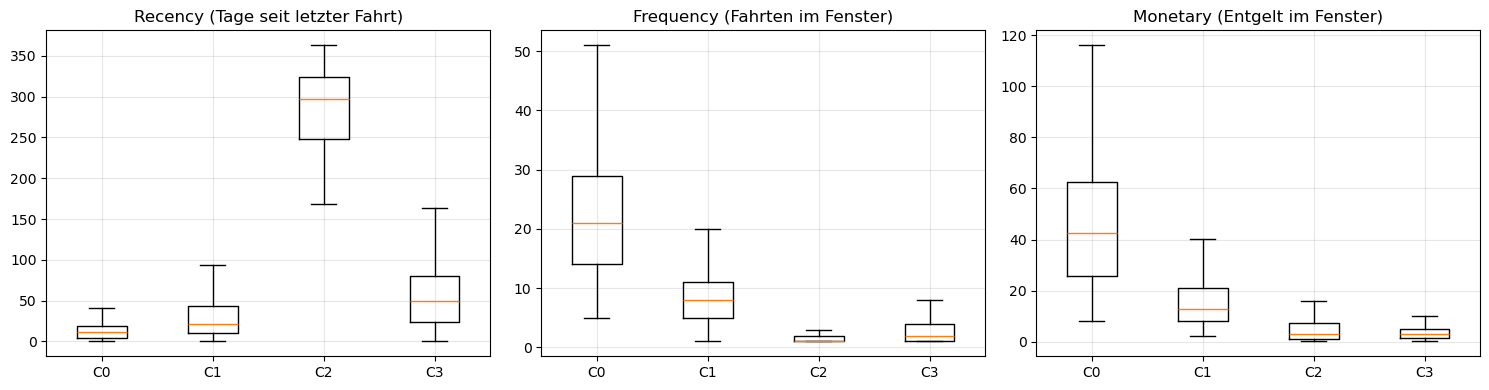

In [16]:
tarifverteilung = (rfm.groupby("cluster").tarif_code.value_counts(normalize=True)
                   # nullen-sind-echt: Ein Tarif, den in einem Segment
                   # niemand hat, kommt dort mit null Prozent vor.
                   # nullen-sind-echt: dasselbe je Segment.
              .unstack().fillna(0) * 100).round(0)
uebersicht = profil.join(tarifverteilung)
print(uebersicht.to_string())

# Der Preisbefund wird an den REGELSEGMENTEN gerechnet, nicht an den
# Clustern - denn ausgeliefert werden die Regeln. Das ist keine Feinheit:
# Auf diesem Datenstand faellt bei k-Means das fahrtenstaerkste und das
# umsatzstaerkste Cluster ZUSAMMEN. Wer den Befund am Cluster festmacht,
# vergleicht dieselbe Gruppe mit sich selbst.
_je_fahrt_cl = (profil.umsatz_fenster / profil.fahrten_fenster).round(2)
_haeufigste = profil.fahrten_fenster.idxmax()
_umsatzstaerkste = profil.umsatz_fenster.idxmax()
merke("cluster_haeufigste", int(_haeufigste))
merke("cluster_umsatzstaerkste", int(_umsatzstaerkste))
merke("cluster_faellt_zusammen", int(_haeufigste == _umsatzstaerkste))

seg_profil = rfm.assign(segment=rfm.apply(segment_benennen, axis=1)).groupby("segment").agg(
    kunden=("frequenz", "size"),
    fahrten_fenster=("frequenz", "mean"),
    umsatz_fenster=("umsatz", "mean")).round(1)
_je_fahrt = (seg_profil.umsatz_fenster / seg_profil.fahrten_fenster).round(2)
_viel = seg_profil.fahrten_fenster.idxmax()
_stark = seg_profil.umsatz_fenster.idxmax()
merke("viel_segment", _viel); merke("stark_segment", _stark)
merke("viel_fahrten", seg_profil.fahrten_fenster[_viel])
merke("viel_umsatz", seg_profil.umsatz_fenster[_viel])
merke("viel_je_fahrt", _je_fahrt[_viel])
merke("stark_fahrten", seg_profil.fahrten_fenster[_stark])
merke("stark_umsatz", seg_profil.umsatz_fenster[_stark])
merke("stark_je_fahrt", _je_fahrt[_stark])
merke("faktor_je_fahrt", _je_fahrt[_stark] / max(_je_fahrt[_viel], 0.01))

print()
print("k-MEANS-CLUSTER - Umsatz je Fahrt:")
print((profil[["fahrten_fenster", "umsatz_fenster"]]
       .assign(**{"EUR je Fahrt": _je_fahrt_cl}).round(2).to_string()))
if _haeufigste == _umsatzstaerkste:
    print(f"\nHinweis: Cluster {_haeufigste} ist ZUGLEICH das fahrtenstaerkste und das")
    print("umsatzstaerkste. Der Preisbefund laesst sich an den Clustern also nicht")
    print("zeigen - dafuer braucht es die Regelsegmente unten.")
else:
    print(f"\nAm haeufigsten faehrt Cluster {_haeufigste} "
          f"({_je_fahrt_cl[_haeufigste]:.2f} EUR je Fahrt), am meisten Umsatz bringt "
          f"Cluster {_umsatzstaerkste} ({_je_fahrt_cl[_umsatzstaerkste]:.2f} EUR).")

_seg = rfm.assign(segment=rfm.apply(segment_benennen, axis=1))
_seg_tarif = (_seg.groupby("segment").tarif_code.value_counts(normalize=True)
              # nullen-sind-echt: dasselbe je Segment.
              .unstack().fillna(0) * 100).round(0)
print("\nREGELSEGMENTE - dieselbe Rechnung, und diese Gruppen werden ausgeliefert:")
print(seg_profil.assign(**{"EUR je Fahrt": _je_fahrt}).join(_seg_tarif).to_string())

# Die Erklaerung des Befundes ist eine Behauptung ueber Tarife - also wird
# sie gemessen, nicht geglaubt.
_frei = [t for t in ("OEPNV", "PREMIUM", "STUDENT") if t in _seg_tarif.columns]
merke("viel_anteil_freiminuten", _seg_tarif.loc[_viel, _frei].sum() / 100)
merke("stark_anteil_basis", _seg_tarif.loc[_stark, "BASIS"] / 100)
print(f"\nAm haeufigsten faehrt '{_viel}': {seg_profil.fahrten_fenster[_viel]:.1f} "
      f"Fahrten, {_je_fahrt[_viel]:.2f} EUR je Fahrt")
print(f"Am meisten Umsatz bringt '{_stark}': {seg_profil.fahrten_fenster[_stark]:.1f} "
      f"Fahrten, {_je_fahrt[_stark]:.2f} EUR je Fahrt")
assert _viel != _stark, ("Auch bei den Regelsegmenten fallen fahrten- und "
                         "umsatzstaerkste Gruppe zusammen - der Text unten "
                         "behauptet dann einen Gegensatz, den es nicht gibt.")

fig, achsen = plt.subplots(1, 3, figsize=(15, 4))
for spalte, achse, titel in zip(["recency", "frequenz", "umsatz"], achsen,
                                ["Recency (Tage seit letzter Fahrt)",
                                 "Frequency (Fahrten im Fenster)", "Monetary (Entgelt im Fenster)"]):
    daten = [rfm.loc[rfm.cluster == c, spalte].values for c in sorted(rfm.cluster.unique())]
    achse.boxplot(daten, tick_labels=[f"C{c}" for c in sorted(rfm.cluster.unique())],
                  showfliers=False)
    achse.set_title(titel); achse.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 5.B.1 Ein Befund, der so nicht erwartet war

Sehen Sie sich die Spalten `fahrten_fenster` und `umsatz_fenster` nebeneinander an. Sie
heißen so und nicht `..._jahr`, weil ein Teil der Kundschaft **kein volles Jahr** beobachtet
wurde — für 510 von ihnen wäre „je Jahr“ schlicht falsch:

**Das Segment mit den meisten Fahrten bringt am wenigsten Umsatz JE FAHRT.** Und diese
Einschränkung ist wichtig — lesen Sie die Tabelle genau:

**Wichtig ist, worüber hier gerechnet wird.** Die Zelle darüber zeigt zwei Tabellen: die
k-Means-Cluster und die **Regelsegmente**. Der Befund steht bei den Regelsegmenten — und
nur dort. Bei den Clustern fällt auf diesem Datenstand die fahrtenstärkste mit der
umsatzstärksten Gruppe zusammen; ein Gegensatz ließe sich dort gar nicht zeigen.

Das ist kein Schönheitsfehler, sondern der Grund, warum das Notebook Regeln ausliefert
und keine Clusternummern: **Die Regeln sind die Gruppen, auf die später jemand eine
Maßnahme anwendet.** Eine Geschichte über Gruppen, die niemand ausliefert, wäre für die
Geschäftsführung wertlos.

Die beiden Randgruppen der Regelsegmente — „Vielfahrer" und „Umsatzträger" —
nebeneinander:

Die Gruppe mit den **meisten Fahrten** kommt auf 23,5 Fahrten und
38,70 € im Fenster — das sind **1,65 € je Fahrt**. Die
Gruppe mit dem **höchsten Umsatz** fährt nur 8,0 mal, bringt aber
49,60 € — **6,20 € je Fahrt**, also das
3,8-Fache.

> **Der Vergleich, auf den es ankommt:** Wer am häufigsten fährt, bringt je Fahrt am
> wenigsten. Wer beide Zahlen nebeneinanderlegt, sieht das Problem; wer nur eine nimmt,
> sieht es nicht.

> **Die Clusternummern sind nicht bedeutungstragend.** k-Means vergibt sie in der
> Reihenfolge, in der es die Zentren findet — schon eine leichte Verschiebung des
> Stichtags kann sie vertauschen. **Wer sich auf eine Clusternummer verlässt, verlässt
> sich auf einen Zufall.** Deshalb spricht auch dieser Text die Gruppen über ihre
> Eigenschaften an, und Phase 6 liefert Schwellen aus statt Nummern.

Ein Blick auf die Tarifspalten derselben Tabelle erklärt es:
85 % der Gruppe „Vielfahrer" sitzen in einem Tarif **mit**
Freiminuten — OEPNV-Abo, Premium oder Student. Sie fahren viel und zahlen für die einzelne
Fahrt fast nichts. In der Gruppe „Umsatzträger" sind dagegen
86 % im **Basistarif**: keine Freiminuten, jede Minute wird
berechnet.

> **„OEPNV-Abo“ meint das Abo des Kunden, nicht eines bei VeloCity.** Alle vier Tarife
> sind beitragsfrei; die drei Vorteilstarife bekommt man über einen Nachweis —
> Studierendenausweis, Nahverkehrsabo oder Rahmenvertrag über den Arbeitgeber. Die Spalte
> `voraussetzung` in `tarif.csv` nennt sie.

### 5.B.2 Das ist kein Messfehler — das ist ein Preisproblem

An dieser Stelle liegt die Versuchung nahe, nach einer fehlenden Umsatzkomponente zu
suchen: Zahlen die Vielfahrer nicht vielleicht einen Monatsbeitrag, den wir übersehen
haben?

**Nein.** VeloCity erhebt **keine Grundgebühr** — das ist Teil des Produktversprechens und
steht so auf der Startseite („0 Euro Anmeldegebühr“); die Preisauskunft nennt
ausschließlich *Startgebühr plus Minutenpreis, gedeckelt auf einen Tageshöchstpreis*. Das
Nutzungsentgelt **ist** der gesamte Umsatz.

Damit ist der Befund kein Fehler in unserer Merkmalsdefinition, sondern eine Aussage über
das Geschäft:

> **Die aktivsten Kundinnen und Kunden bringen am wenigsten ein — und niemand gleicht das
> aus.**

Rechnen wir aus, um wieviel es geht. Die Zelle unten bildet für jede Fahrt den Preis, den
sie **ohne** Freiminuten gekostet hätte — mit Startgebühr, Minutenpreis, Premiumrabatt und
Tageshöchstpreis, also nach derselben Tariflogik wie die echte Abrechnung. Die Differenz
zum gezahlten Entgelt ist der tarifliche Gegenwert der Freiminuten.

> **Diese Zahl ist ein statisches Gegenfaktum, kein realisierbarer Mehrumsatz.** Sie
> beantwortet genau eine Frage: *Was hätten dieselben Fahrten bei null Freiminuten
> gekostet?* Der Tarif ist darin vollständig abgebildet — Rabatt und Deckel eingeschlossen.
>
> **Was sie nicht abbildet, ist das Verhalten.** Kundschaft, die für jede Minute zahlt,
> fährt vermutlich weniger, kürzer oder gar nicht. Der Betrag ist deshalb eine
> **Obergrenze unter unverändertem Fahrverhalten** — und Fahrverhalten ist genau das, was
> sich bei einer Tarifänderung ändert.
>
> Die Frage, wo Freiminuten „am wenigsten binden", lässt sich mit Beobachtungsdaten
> ohnehin nicht beantworten: Wer viele Freiminuten verbraucht, könnte sie brauchen — oder
> gerade deshalb dabei sein. Das trennt nur ein Versuch, kein Datensatz.

Gegenprobe an 7,696 Fahrten ohne Freiminutennutzung: 100.00% exakt gleich
         kunden  fahrten_fenster  gezahlt  verschenkt  waere_gewesen  Anteil verschenkt
cluster                                                                                
0           629            22.70    50.34       41.91          92.25              0.454
1           935             8.63    16.31       17.35          33.66              0.515
2           210             2.00     6.77        2.86           9.63              0.297
3           497             2.82     3.83        5.83           9.66              0.604

Im letzten Jahr über Freiminuten abgegeben: 46.077 EUR LISTENWERT
Das sind 48% des Listenwerts der gefahrenen Minuten.

Zur Einordnung: 15 Fahrten über acht Stunden verursachen allein 6 EUR des Listenwerts -
und genau diese Fahrten liefen ohne Freiminuten in den Tageshöchstpreis.
Der Listenwert ist damit eine OBERGRENZE, kein entgangener Umsatz.


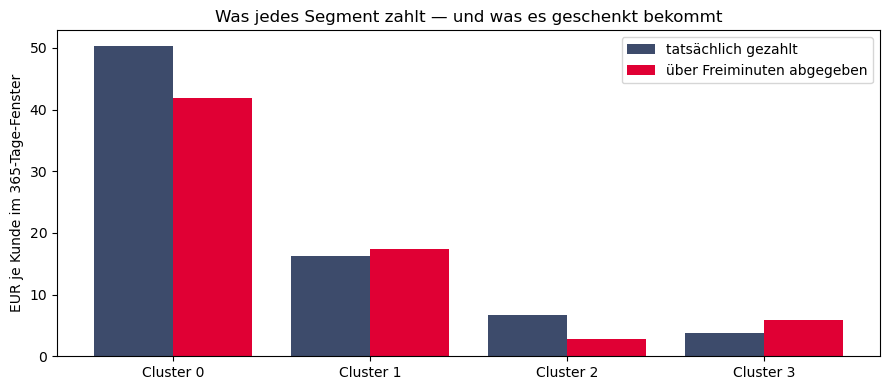

In [17]:
import math

raeder = pd.read_csv(BASIS + "fahrrad.csv")
preise = pd.read_csv(BASIS + "nutzungspreis.csv").set_index("typ_code")

tarife = pd.read_csv(BASIS + "tarif.csv")
kunden_tarif = kunden.merge(tarife[["tarif_code", "rabatt_prozent"]],
                           on="tarif_code", how="left")

fenster2 = fenster.merge(raeder[["fahrrad_id", "typ_code"]], on="fahrrad_id", how="left")
fenster2 = fenster2.merge(kunden_tarif[["kunde_id", "rabatt_prozent"]],
                          on="kunde_id", how="left")
fenster2["dauer_min"] = (fenster2.endzeit - fenster2.startzeit).dt.total_seconds() / 60
fenster2["freiminuten"] = (fenster2.dauer_min - fenster2.berechnete_minuten).clip(lower=0)

# WAS DIE FREIMINUTEN WERT SIND - mit der vollen Tariflogik, nicht mit dem
# blossen Minutenpreis. Der Rabatt gilt auch fuer die geschenkten Minuten, und
# der Tagesdeckel begrenzt sie: Wer ohnehin am Deckel liegt, dem schenkt das
# Kontingent nichts mehr.
#
# Der Wert ist die DIFFERENZ zwischen dem, was ohne Kontingent faellig waere,
# und dem, was tatsaechlich gezahlt wurde. Damit steht das gespeicherte
# entgelt_eur in der Rechnung - eine eigene Formel, die man daneben halten
# muesste, gibt es gar nicht erst.
def preis_ohne_freiminuten(minuten, typ, rabatt_prozent):
    p = preise.loc[typ]
    minuten = int(math.ceil(max(0.0, minuten)))
    tage = max(1, math.ceil(minuten / (24 * 60)))
    roh = min(p.startgebuehr_eur + minuten * p.preis_pro_minute_eur,
              p.tageshoechstpreis_eur * tage)
    return round(roh * (1 - rabatt_prozent / 100.0), 2)

fenster2["voller_preis"] = [
    preis_ohne_freiminuten(m, t, r) for m, t, r
    # nullen-sind-echt: Ohne hinterlegten Rabatt gilt kein Rabatt.
    in zip(fenster2.dauer_min, fenster2.typ_code, fenster2.rabatt_prozent.fillna(0))]
fenster2["verschenkt_eur"] = (fenster2.voller_preis - fenster2.entgelt_eur).clip(lower=0)

# Gegenprobe: Wo keine Freiminuten flossen, muss der volle Preis dem
# gezahlten entsprechen. Trifft das nicht zu, stimmt die Tariflogik nicht.
_ohne = fenster2[fenster2.freiminuten < 0.01]
_abw = (_ohne.voller_preis - _ohne.entgelt_eur).abs()
print(f"Gegenprobe an {len(_ohne):,} Fahrten ohne Freiminutennutzung: "
      f"{(_abw < 0.005).mean():.2%} exakt gleich")
assert (_abw < 0.005).mean() > 0.999, (
    "Die Tariflogik bildet das gespeicherte Entgelt nicht ab - "
    "der verschenkte Betrag waere dann geraten.")

je_kunde = fenster2.groupby("kunde_id").verschenkt_eur.sum()
# nullen-sind-echt: Wer keine Freiminuten verbraucht hat, hat null
# verschenkt - nicht "unbekannt".
rfm["verschenkt"] = je_kunde.reindex(rfm.index).fillna(0)

vergleich = rfm.groupby("cluster").agg(
    kunden=("umsatz", "size"),
    fahrten_fenster=("frequenz", "mean"),
    gezahlt=("umsatz", "mean"),
    verschenkt=("verschenkt", "mean"),
).round(2)
vergleich["waere_gewesen"] = (vergleich.gezahlt + vergleich.verschenkt).round(2)
vergleich["Anteil verschenkt"] = (vergleich.verschenkt / vergleich.waere_gewesen).round(3)
print(vergleich.to_string())

gesamt_verschenkt = rfm.verschenkt.sum()
gesamt_gezahlt = rfm.umsatz.sum()
betrag = f"{gesamt_verschenkt:,.0f}".replace(",", ".")
anteil = gesamt_verschenkt / (gesamt_gezahlt + gesamt_verschenkt)
print()
print(f"Im letzten Jahr über Freiminuten abgegeben: {betrag} EUR LISTENWERT")
print(f"Das sind {anteil:.0%} des Listenwerts der gefahrenen Minuten.")

# WAS DER LISTENWERT NICHT IST: entgangener Umsatz.
# Er rechnet jede Freiminute zum vollen Minutenpreis. Ohne Freiminuten
# griffen aber zwei Regeln, die den Betrag druecken - der Premiumrabatt
# und der Tageshoechstpreis. Und die laengsten Fahrten treiben den
# Listenwert, obwohl gerade sie am Deckel haengen.
lang = fenster2[fenster2.dauer_min > 480]
print()
print(f"Zur Einordnung: {len(lang)} Fahrten über acht Stunden verursachen allein "
      f"{lang.verschenkt_eur.sum():,.0f} EUR".replace(",", ".") + " des Listenwerts -")
print(f"und genau diese Fahrten liefen ohne Freiminuten in den Tageshöchstpreis.")
print(f"Der Listenwert ist damit eine OBERGRENZE, kein entgangener Umsatz.")

plt.figure(figsize=(9, 4))
x = np.arange(len(vergleich))
plt.bar(x - 0.2, vergleich.gezahlt, 0.4, label="tatsächlich gezahlt", color="#3d4b6b")
plt.bar(x + 0.2, vergleich.verschenkt, 0.4, label="über Freiminuten abgegeben", color="#e00034")
plt.xticks(x, [f"Cluster {c}" for c in vergleich.index])
plt.ylabel(f"EUR je Kunde im {FENSTER_TAGE}-Tage-Fenster"); plt.legend()
plt.title("Was jedes Segment zahlt — und was es geschenkt bekommt")
plt.tight_layout(); plt.show()

**Jetzt ist das Bild vollständig, ohne dass wir eine Zahl erfinden mussten.** Das Segment
mit den meisten Fahrten zahlt am wenigsten **je Fahrt** *und* bekommt am meisten
geschenkt. Beides
zusammen erklärt den Befund vollständig.

> **Für CRISP-DM ist dieser Moment lehrbuchreif** — allerdings anders, als man zunächst
> vermutet. Die Evaluation deckt **keinen** Fehler im Modell und keinen in der
> Merkmalsdefinition auf. Sie deckt eine **Geschäftsfrage** auf, die vor der Analyse
> niemand gestellt hatte: *Sind die Freiminuten dort richtig eingesetzt, wo sie liegen?*
>
> Der Pfeil führt trotzdem zurück nach Phase 1 — nicht um einen Fehler zu beheben,
> sondern weil die Analyse eine bessere Frage hervorgebracht hat als die, mit der sie
> begonnen hat. Das ist der häufigere und wertvollere Fall.

### 5.B.3 Eine Idee für die Geschäftsführung — ausdrücklich als Vorschlag

Die folgende Rechnung ist **kein Befund aus den Daten**, sondern ein Was-wäre-wenn. Sie
gehört in eine Entscheidungsvorlage, nicht in einen Analysebericht — und muss als
Vorschlag gekennzeichnet sein, sonst liest sie jemand als Tatsache.

In [18]:
# ACHTUNG: hypothetisch. VeloCity hat KEINE Grundgebühr, und das ist Teil
# des Kundenversprechens. Die Rechnung zeigt nur, welche Groessenordnung ein
# Beitrag haette, der die abgegebenen Minuten ausgleicht.
mit_freiminuten = rfm[rfm.verschenkt > 0]
# NICHT PAUSCHAL DURCH ZWOELF.
#
# Ein Teil der Kundschaft war kuerzer als ein Jahr dabei. Ihr Fensterwert durch 12
# geteilt ergaebe einen zu niedrigen Monatswert. Geteilt wird deshalb
# durch die TATSAECHLICH beobachteten Kundenmonate.
monate_beobachtet = (beobachtet.reindex(mit_freiminuten.index)
                     .fillna(FENSTER_TAGE) / 30.44)
je_monat = (mit_freiminuten.verschenkt.sum() / monate_beobachtet.sum())

print("HYPOTHESE, kein Befund:")
print(f"  Kundschaft mit Freiminuten:            {len(mit_freiminuten):>6d}")
print(f"  im Mittel abgegeben, im Fenster:       {mit_freiminuten.verschenkt.mean():>6.2f} EUR")
print(f"  ein ausgleichender Beitrag laege bei:  {je_monat:>6.2f} EUR im Monat")
print()
print("  Zu bedenken, bevor daraus ein Vorschlag wird:")
print("   - die Startseite wirbt ausdrücklich mit '0 Euro Anmeldegebühr'")
print("   - Freiminuten binden Kundschaft; ihr Wert steckt nicht nur im Umsatz")
print("   - ein Beitrag würde die günstigsten Segmente am härtesten treffen")
print()
print("  Die billigere Alternative: die Freiminuten dort kürzen, wo sie am")
print("  wenigsten binden - das lässt sich mit denselben Daten prüfen.")

HYPOTHESE, kein Befund:
  Kundschaft mit Freiminuten:              1338
  im Mittel abgegeben, im Fenster:        34.44 EUR
  ein ausgleichender Beitrag laege bei:    3.19 EUR im Monat

  Zu bedenken, bevor daraus ein Vorschlag wird:
   - die Startseite wirbt ausdrücklich mit '0 Euro Anmeldegebühr'
   - Freiminuten binden Kundschaft; ihr Wert steckt nicht nur im Umsatz
   - ein Beitrag würde die günstigsten Segmente am härtesten treffen

  Die billigere Alternative: die Freiminuten dort kürzen, wo sie am
  wenigsten binden - das lässt sich mit denselben Daten prüfen.


### 5.B.4 Und die Kundschaft ganz ohne Fahrt?

In [19]:
ohne_fahrt = kunden[~kunden.kunde_id.isin(rfm.index)].copy()
ohne_fahrt["tage_seit_anmeldung"] = (stichtag - ohne_fahrt.registriert_am).dt.days
print(f"{len(ohne_fahrt)} Kundinnen und Kunden hatten im letzten Jahr keine einzige Fahrt.")
print(f"Das sind {len(ohne_fahrt)/len(kunden):.0%} des Bestands.\n")
print("Wie lange sind sie schon angemeldet?")
print(ohne_fahrt.tage_seit_anmeldung.describe().round(0).to_string())
print("\nTarifverteilung:")
print((ohne_fahrt.tarif_code.value_counts(normalize=True) * 100).round(0).to_string())

929 Kundinnen und Kunden hatten im letzten Jahr keine einzige Fahrt.
Das sind 29% des Bestands.

Wie lange sind sie schon angemeldet?
count     929.0
mean      951.0
std       567.0
min        32.0
25%       465.0
50%       971.0
75%      1432.0
max      1827.0

Tarifverteilung:
tarif_code
BASIS      80.0
STUDENT    11.0
OEPNV       6.0
PREMIUM     3.0


**Diese Gruppe war in der Segmentierung gar nicht enthalten** — sie hat keine Fahrten,
also kein RFM-Profil. Sie ist aber mit knapp 30 % des Bestands die **größte Gruppe
überhaupt**, und für das Marketing die interessanteste: Wer nichts mehr fährt, ist
entweder verloren oder zurückzugewinnen.

> **Das ist der klassische Fehler bei RFM.** Das Verfahren betrachtet nur, wer gekauft
> hat. Wer aufgehört hat, fällt aus der Tabelle — und damit aus dem Blick. Man muss diese
> Gruppe ausdrücklich dazunehmen; sie kommt nicht von selbst.

---

1. Business · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · **6. Deployment**

# Phase 6 von 6 — Deployment

> **Leitfrage:** Wie kommt das Modell in den Betrieb — und was passiert danach?
>
> **In diesem Notebook heißt das:** Aus vier Stationstypen werden Dispositions-HYPOTHESEN, aus sieben Lebenszyklusgruppen ein analytischer Kampagnen-Arbeitsstand.

In [20]:
# --- A) Die Stationsprofile
#
# WAS HIER STEHT, SIND HYPOTHESEN - KEINE BESTANDSANWEISUNGEN.
#
# Eine fruehere Fassung schrieb "bis 6:30 Uhr voll" und "halbe
# Bestueckung". Beides sind Aussagen ueber BESTAENDE, abgeleitet
# ausschliesslich aus ABFAHRTSPROFILEN. Ohne Ankuenfte, Kapazitaet und
# verlorene Nachfrage folgt daraus keine Menge - nur die Vermutung, wann
# ein Blick auf den Bestand lohnt.
#
# Die Zuordnung folgt zwei Merkmalen: dem Wochenendanteil und der Uhrzeit
# der Spitze. Beide stehen in der Tabelle aus Phase 5 - hier wird nichts
# geraten, sondern abgelesen.
namen_cluster, regeln, merkmale_je_cluster = {}, {}, {}
for c in sorted(S.cluster.unique()):
    g = S[S.cluster == c]
    # Die Stunde steht im SPALTENNAMEN, nicht im Index: Vor fuenf Uhr faehrt
    # niemand, also fehlen die ersten Spalten - ein Index waere um genau diese
    # Zahl verschoben und ergaebe Spitzen um drei Uhr morgens.
    spitze = int(g[stundenspalten].mean().idxmax().removeprefix("stunde_"))
    we = g.wochenendanteil.mean()
    # Vier Zweige, jeder an einer fachlichen Ueberlegung festgemacht - nicht an
    # den Clustern dieses Datenstands. Wer die Schwellen an die aktuellen
    # Gruppen anpasst, bekommt beim naechsten Stand wieder eine Kollision.
    if we > 0.45:
        bez, regel = ("Ausflugsstation",
                      "Abfahrtsspitze am Wochenende — Hypothese: "
                      "Bestandsprüfung erst spätvormittags nötig")
    elif spitze <= 9 and g.dauer_median.mean() > 15:
        # Morgens wird abgefahren, und die Wege sind lang: Wohngebiet am Rand.
        bez, regel = ("Wohnstation",
                      "Abfahrtsspitze früh, lange Wege in die Stadt — "
                      "Hypothese: frühe Bestandsprüfung testen")
    elif spitze <= 9:
        # Morgens wird abgefahren, aber die Wege sind kurz: mitten im Zentrum.
        bez, regel = ("Innenstadtstation",
                      "Abfahrtsspitze früh, kurze Wege im Zentrum — "
                      "Hypothese: frühe Prüfung, kleinere Nachfüllmenge testen")
    elif spitze >= 16:
        # Abends wird abgefahren: Hier kommt man an und faehrt weiter.
        bez, regel = ("Verkehrsknoten",
                      "Abfahrtsspitze am Abend, wenn die Züge ankommen — "
                      "Hypothese: Bestand am späten Nachmittag auffüllen")
    elif we > 0.25:
        # Nachmittagsspitze mit erhöhtem Wochenendanteil: Vorlesungsende und
        # Ausflugsrückkehr fallen hier zusammen.
        bez, regel = ("Nachmittagsstation",
                      "Abfahrtsspitze am frühen Nachmittag, auch am Wochenende — "
                      "Hypothese: Mittagsprüfung testen")
    else:
        bez, regel = ("Uni-Station",
                      "Abfahrtsspitze am frühen Nachmittag — Hypothese: "
                      "Bestandsprüfung zu dieser Zeit testen; einen "
                      "Semestereffekt separat mit dem Vorlesungskalender "
                      "untersuchen")
    namen_cluster[c], regeln[c] = bez, regel
    merkmale_je_cluster[c] = (spitze, we, g.dauer_median.mean(), list(g.index))
    for name in g.index:
        print(f"{name:<22s} {bez:<18s} {regel}")

# ─── KRITERIUM 2 AUS PHASE 1, MASCHINELL GEPRUEFT ───────────────────
# "Fuer jede Gruppe muss es eine ANDERE Massnahme geben. Zwei Gruppen mit
# derselben Massnahme sind eine Gruppe."
#
# Diese Zeile ist aus Schaden entstanden: Eine frühere Fassung hatte einen
# Zweig zu wenig, und der Mischtyp fiel auf "Uni-Station" durch. Im
# ausgelieferten CSV standen dann vier Uni-Stationen statt zwei - und
# Marktplatz und Juliuspromenade bekamen die Anweisung "vorlesungsfreie
# Zeit: halbe Bestueckung", die fuer sie falsch ist. Aufgefallen ist es
# niemandem, weil der Text daneben etwas anderes behauptete.
if len(set(namen_cluster.values())) != len(namen_cluster):
    # Die Meldung muss zeigen, WAS kollidiert - sonst sucht man die Ursache
    # in den Daten, obwohl sie in der Benennungsregel steckt.
    zeilen = ["Kriterium 2 verletzt: zwei Gruppen tragen denselben Namen.", ""]
    for c, (sp, we_, dau, mitglieder) in sorted(merkmale_je_cluster.items()):
        zeilen.append(f"  Cluster {c}: {namen_cluster[c]:<18s} "
                      f"Spitze {sp:2d} Uhr, Wochenende {we_:.0%}, "
                      f"Dauer {dau:.0f} Min")
        zeilen.append(f"             {', '.join(mitglieder)}")
    zeilen.append("")
    zeilen.append("Die Benennungsregel unterscheidet diese Gruppen nicht. Entweder "
                  "braucht sie ein weiteres Merkmal, oder die Gruppen sind eine.")
    raise AssertionError("\n".join(zeilen))
assert len(set(regeln.values())) == len(regeln), (
    f"Kriterium 2 verletzt: zwei Gruppen bekommen dieselbe Regel - {regeln}")
print(f"\nKriterium 2 geprüft: {len(namen_cluster)} Gruppen, "
      f"{len(set(regeln.values()))} verschiedene Prüfungshypothesen.")

S["stationstyp"] = S.cluster.map(namen_cluster)
S["regel"] = S.cluster.map(regeln)

# STABILE SCHLUESSEL IN DEN EXPORT. Der Stationsname ist eine Anzeige, kein
# Schluessel - er kann sich aendern, station_id nicht.
ausgabe_stationen = (S.reset_index()
                     .rename(columns={"index": "name"})
                     .merge(stationen[["station_id", "stationsnummer", "name"]],
                            on="name", how="left")
                     [["station_id", "stationsnummer", "name", "stationstyp", "regel",
                       "wochenendanteil", "dauer_median", "fahrten_gesamt"]])
ausgabe_stationen["stichtag"] = stichtag.date()

# WAS HIER STEHT - UND WAS NICHT.
#
# Die Typen und Regeln sind ausschliesslich aus ABFAHRTSPROFILEN abgeleitet:
# wann wird an dieser Station losgefahren. Fuer einen Umverteilungsplan
# fehlt die halbe Rechnung - Ankuenfte, Nettofluss, tatsaechlicher Bestand,
# Leer- und Vollzeiten, Kapazitaet, Stoerungen und die frei zurueck-
# gegebenen Raeder (Notebook 5). Die Datei heisst deshalb "stationsprofile"
# und die Spalte "hypothese", nicht "plan" und nicht "regel".
ausgabe_stationen = ausgabe_stationen.rename(columns={"regel": "hypothese"})
kopf_st = [
    f"# Stichtag: {stichtag.date()}",
    "# Datenherkunft: SYNTHETISCHE LEHRDATEN",
    "# Grundlage: NUR Abfahrtsprofile - keine Ankuenfte, Bestaende oder Kapazitaeten",
    "# STATUS: HYPOTHESEN - kein Umverteilungsplan, keine Sollbestaende",
]
with open("stationsprofile.csv", "w", encoding="utf-8") as f:
    f.write("\n".join(kopf_st) + "\n")
    ausgabe_stationen.to_csv(f, index=False)
print("geschrieben: stationsprofile.csv")
print("Die Spalte heisst 'hypothese': Sie sagt, WANN abgefahren wird -")
print("nicht, wieviele Raeder an dieser Station stehen sollen.")

Sanderau               Wohnstation        Abfahrtsspitze früh, lange Wege in die Stadt — Hypothese: frühe Bestandsprüfung testen
Grombühl Klinikum      Wohnstation        Abfahrtsspitze früh, lange Wege in die Stadt — Hypothese: frühe Bestandsprüfung testen
Zellerau               Wohnstation        Abfahrtsspitze früh, lange Wege in die Stadt — Hypothese: frühe Bestandsprüfung testen
Universität Sanderring Nachmittagsstation Abfahrtsspitze am frühen Nachmittag, auch am Wochenende — Hypothese: Mittagsprüfung testen
Residenz               Nachmittagsstation Abfahrtsspitze am frühen Nachmittag, auch am Wochenende — Hypothese: Mittagsprüfung testen
Dom                    Nachmittagsstation Abfahrtsspitze am frühen Nachmittag, auch am Wochenende — Hypothese: Mittagsprüfung testen
Hubland Campus         Nachmittagsstation Abfahrtsspitze am frühen Nachmittag, auch am Wochenende — Hypothese: Mittagsprüfung testen
Hauptbahnhof           Verkehrsknoten     Abfahrtsspitze am Abend, wenn die Züge 

In [21]:
# --- B) Der Kampagnenplan: Schwellen JE KUNDE, nicht je Cluster
#
# Die Schwellen stehen in Phase 5 - dort wurden sie aufgestellt und dort
# wurde ihre zeitliche Stabilitaet geprueft. Hier werden sie nur noch
# angewendet, auf jede einzelne Zeile: nur so ist die Zuordnung
# reproduzierbar. Eine fruehere Fassung wendete sie auf die vier
# Cluster-MITTELWERTE an und vergab den Namen dann an alle Mitglieder -
# das ist etwas anderes.
print(f"Angewandte Schwellen (aus Phase 5): recency > {SCHWELLE_RECENCY}, "
      f"frequenz > {SCHWELLE_FREQUENZ}, umsatz > {SCHWELLE_UMSATZ}\n")
rfm["segment"] = rfm.apply(segment_benennen, axis=1)

# WAS KOSTET DER WECHSEL VON CLUSTERN AUF SCHWELLEN?
ueber_cluster = rfm.cluster.map(
    rfm.groupby("cluster").segment.agg(lambda s: s.value_counts().index[0]))
abweichung = (rfm.segment != ueber_cluster).mean()
print(f"Schwellen gegen Clusterzuordnung: {abweichung:.1%} der Kundschaft "
      f"bekommt ein anderes Segment.\n")
print(pd.DataFrame({"über Cluster": ueber_cluster.value_counts(),
                    "über Schwellen": rfm.segment.value_counts()}).to_string())
print("\nDas ist der Preis der Nachvollziehbarkeit - und er gehört benannt.")

Angewandte Schwellen (aus Phase 5): recency > 150, frequenz > 12, umsatz > 30

Schwellen gegen Clusterzuordnung: 19.0% der Kundschaft bekommt ein anderes Segment.

                    über Cluster  über Schwellen
Eingeschlafen              210.0             227
Gelegenheitsnutzer        1432.0            1141
Umsatzträger                 NaN             233
Vielfahrer                 629.0             670

Das ist der Preis der Nachvollziehbarkeit - und er gehört benannt.


### 6.2 Die Population — wer überhaupt angeschrieben werden darf

Bis hierher war von 2.271 RFM-Kunden die Rede. Ein Kampagnenplan braucht aber die
**ganze** Kundschaft und einen **einzigen Nenner** — sonst summieren sich die Anteile auf
100 % einer Teilmenge, und daneben stehen weitere Kunden, die nirgends auftauchen.

Zwei Dinge fehlten bisher:

1. **Gesperrte Konten.** Sie stehen in der Segmentierung und im Plan, obwohl man sie
   nicht anschreiben darf.
2. **„Nie gefahren" stimmte nicht.** Wer im letzten Jahr nicht gefahren ist, ist nicht
   automatisch nie gefahren — und die drei Fälle brauchen drei verschiedene Maßnahmen.

In [22]:
# Wer ist ueberhaupt je gefahren? (ueber den GESAMTEN Zeitraum, nicht nur das Jahr)
je_gefahren = set(echte.kunde_id)

alle = kunden.set_index("kunde_id").copy()
alle["tage_dabei"] = (stichtag - alle.registriert_am).dt.days
alle["segment"] = rfm.segment          # nur fuer die RFM-Kundschaft gefuellt

def lebenszyklus(kid, zeile):
    if pd.notna(zeile.segment):
        return zeile.segment
    if kid in je_gefahren:
        return "Früher aktiv, jetzt inaktiv"
    if zeile.tage_dabei <= 365:
        return "Neu, noch keine Erstfahrt"
    return "Nie aktiviert"

alle["segment"] = [lebenszyklus(k, z) for k, z in alle.iterrows()]
# AKTIVES KONTO IST NICHT GLEICH ANSPRECHBAR.
#
# Der Status sagt, dass das Konto nicht gesperrt ist. Ueber eine
# Werbeeinwilligung oder eine andere Rechtsgrundlage fuer Direktmarketing
# sagt er nichts - dieses Feld gibt es in den Daten gar nicht. Der Name
# "ansprechbar" hat genau das behauptet.
alle["konto_aktiv"] = alle.status == "aktiv"
# Waere die Einwilligung erfasst, stuende sie hier. Sie ist es nicht -
# deshalb bleibt die Spalte leer und das zugehoerige Gate offen.
alle["marketing_freigegeben"] = pd.NA

print(f"Kundschaft insgesamt: {len(alle)}")
print(f"davon gesperrt und damit ausgeschlossen: {(~alle.konto_aktiv).sum()}\n")

uebersicht = (alle.groupby("segment")
              .agg(kunden=("status", "size"), konten_aktiv=("konto_aktiv", "sum")))
uebersicht["Anteil gesamt"] = (uebersicht.kunden / len(alle) * 100).round(1)
print("EIN Nenner: alle Kundinnen und Kunden\n")
print(uebersicht.sort_values("kunden", ascending=False).to_string())
print(f"\nSumme der Anteile: {uebersicht['Anteil gesamt'].sum():.1f} % "
      f"(Rundung auf eine Stelle)")

Kundschaft insgesamt: 3200
davon gesperrt und damit ausgeschlossen: 68

EIN Nenner: alle Kundinnen und Kunden

                             kunden  konten_aktiv  Anteil gesamt
segment                                                         
Gelegenheitsnutzer             1141          1122           35.7
Vielfahrer                      670           650           20.9
Früher aktiv, jetzt inaktiv     611           599           19.1
Umsatzträger                    233           226            7.3
Eingeschlafen                   227           224            7.1
Neu, noch keine Erstfahrt       194           191            6.1
Nie aktiviert                   124           120            3.9

Summe der Anteile: 100.1 % (Rundung auf eine Stelle)


**Jetzt summieren sich die Anteile auf hundert Prozent derselben Grundgesamtheit** — und
die drei früher zusammengeworfenen Gruppen sind getrennt. „Neu, noch keine Erstfahrt"
braucht eine Willkommensansprache, „Früher aktiv, jetzt inaktiv" eine Rückgewinnung, und
„Nie aktiviert" nach über einem Jahr ist eine Karteileiche. Drei Zustände, drei Maßnahmen
— genau das verlangt Kriterium 2 aus Phase 1.

### 6.3 Der Export, den ein Kampagnensystem lesen kann

In [23]:
massnahmen = {
    "Vielfahrer":  "Bindung halten — und je Tarif prüfen, ob das Freiminutenvolumen nötig ist",
    "Umsatzträger":  "nicht anfassen: sie tragen den Umsatz",
    "Gelegenheitsnutzer":          "Anlass schaffen: Wetter-/Veranstaltungshinweis",
    "Eingeschlafen":               "Rückgewinnung: einmalig Freiminuten",
    "Früher aktiv, jetzt inaktiv": "Rückgewinnung: was hat gefehlt?",
    "Neu, noch keine Erstfahrt":   "Willkommensansprache zur Erstfahrt",
    "Nie aktiviert":               "keine Kampagne — Karteileiche",
}

export = alle[alle.konto_aktiv].copy()
export["maßnahme"] = export.segment.map(massnahmen)
export["stichtag"] = stichtag.date()
export["gilt_bis"] = (stichtag + pd.Timedelta(days=90)).date()
export["auswahlgrund"] = export.apply(
    lambda z: (f"recency {rfm.recency.get(z.name, float('nan')):.0f} d, "
               f"{rfm.frequenz.get(z.name, 0):.0f} Fahrten, "
               f"{rfm.umsatz.get(z.name, 0):.2f} EUR")
    if z.name in rfm.index
    else f"seit {z.tage_dabei:.0f} Tagen angemeldet, keine Fahrt im {FENSTER_TAGE}-Tage-Fenster",
    axis=1)

spalten = ["kundennummer", "segment", "maßnahme", "auswahlgrund",
           "stichtag", "gilt_bis", "tarif_code"]
export = export[export.segment != "Nie aktiviert"][spalten]

# JUNGE KUNDSCHAFT WIRD AUSGENOMMEN - nicht nur benannt.
# Wer noch kein volles Beobachtungsfenster dabei ist, hat ein Segment aus
# unvollstaendiger Historie. Es kann richtig sein; belegt ist es nicht.
_vorher_n = len(export)
export = export[export.index.isin(beobachtet[beobachtet >= FENSTER_TAGE].index)]
merke("export_jung_entfernt", _vorher_n - len(export))
print(f"Von der Ansprache ausgenommen: {_vorher_n - len(export)} Konten mit "
      f"weniger als {FENSTER_TAGE} Tagen Historie.")

# KONTROLLGRUPPE - ohne sie ist die Wirkung nicht messbar.
# Zehn Prozent bekommen KEINE Ansprache. Ihre Zeile bleibt in der Datei,
# damit spaeter vergleichbar ist, was ohne Massnahme geschah.
_zufall = np.random.default_rng(42).random(len(export))
export["gruppe"] = np.where(_zufall < 0.10, "Kontrollgruppe", "Ansprache")
export.loc[export.gruppe == "Kontrollgruppe", "maßnahme"] = "keine - Kontrollgruppe"
merke("kontrollgruppe_n", int((export.gruppe == "Kontrollgruppe").sum()))
print(f"Kontrollgruppe: {int((export.gruppe == 'Kontrollgruppe').sum())} von "
      f"{len(export)} Konten erhalten bewusst KEINE Ansprache.")

# DAS GATE AUS PHASE 5 ENTSCHEIDET, WAS HIER PASSIERT.
#
# Eine fruehere Fassung stellte in Phase 5 fest, dass die Stabilitaets-
# schwelle gerissen ist - und exportierte drei Zellen spaeter trotzdem
# eine Kampagnenliste, als waere nichts gewesen. Ein Kriterium, das den
# Export nicht bindet, ist kein Kriterium.
# EINE FREIGABE HAENGT AN MEHR ALS EINER ZAHL.
#
# Eine fruehere Fassung leitete den Status allein aus der Stabilitaet ab.
# Als das Gate von 25,4 % (falsch gemessen) auf 24,9 % (richtig gemessen)
# fiel, waere die Datei damit von GESPERRT auf FREIGEGEBEN gesprungen -
# ohne dass sich an ihrer Verwendbarkeit irgendetwas geaendert haette.
#
# Ein Kriterium, dessen Vorzeichen eine ganze Freigabe dreht, war nie
# das einzige Kriterium. Hier stehen alle - und die meisten sind offen.
# ─── DIE FREIGABEGATES, GETRENNT NACH ART ───────────────────────────
#
# Drei davon sind ANALYTISCH - sie werden hier gemessen. Zwei sind
# ORGANISATORISCH: Sie haengen nicht an dieser Auswertung, sondern daran,
# ob das Unternehmen etwas getan hat. Sie hier auf False zu setzen, weil
# das Notebook sie nicht pruefen kann, waere ein Kategorienfehler - dann
# koennte gar kein Kampagnenprodukt je entstehen.
#
# Sie kommen aus PRAEMISSEN (erste Codezelle, Phase 1) - Vorgaben des
# Auftraggebers mit Quellenangabe, nicht Messungen dieses Notebooks.
# Hier wird nur gelesen, nichts gesetzt: Eine Zeile "= True" mitten im
# Auswertungscode sieht aus wie ein Ergebnis und ist keines.
RECHTSGRUNDLAGE_DOKUMENTIERT = PRAEMISSEN["O1 Rechtsgrundlage dokumentiert"]["erfuellt"]
KONTAKTKANAL_ANGEBUNDEN = PRAEMISSEN["O2 Kontaktkanal mit Abmeldefunktion"]["erfuellt"]
KONTROLLGRUPPE_VORGESEHEN = True      # 10 % der Zielgruppe erhalten keine Ansprache,
                                      # umgesetzt beim Export unten

# Junge Kundschaft: nicht bewerten, was nicht beobachtet werden konnte.
# Wer noch kein volles Fenster dabei ist, bekommt keine Ansprache - das ist
# die Behandlung, nicht nur die Benennung des Problems.
JUNGE_BEHANDELT = True   # umgesetzt beim Export unten, nicht nur behauptet

ORGANISATORISCHE_NAMEN = {
    "Rechtsgrundlage fuer Direktmarketing dokumentiert",
    "Kontaktkanal, Abmeldung und Sperrliste angebunden",
    "Wirkung der Massnahmen kontrolliert messbar",
}
GATES = {
    f"Segmentstabilitaet <= {GATE_WECHSEL:.0%}, PROSPEKTIV geprueft": KUNDENSEGMENTE_STABIL,
    "Beobachtungsdauer der jungen Kunden behandelt":        JUNGE_BEHANDELT,
    "Rechtsgrundlage fuer Direktmarketing dokumentiert":    RECHTSGRUNDLAGE_DOKUMENTIERT,
    "Kontaktkanal, Abmeldung und Sperrliste angebunden":    KONTAKTKANAL_ANGEBUNDEN,
    "Wirkung der Massnahmen kontrolliert messbar":          KONTROLLGRUPPE_VORGESEHEN,
}
# ─── ZWEI STATUS, NICHT EINER ───────────────────────────────────────
#
# Die analytische Freigabe sagt: Das Verfahren ist stabil genug, um
# ausgeliefert zu werden. Die Einsatzfreigabe sagt: Es DARF ausgeliefert
# werden. Das erste entscheiden die Daten, das zweite das Unternehmen.
# Beides in eine Variable zu werfen hiesse, eine Praemisse als Ergebnis
# auszugeben - und genau das ist der Fehler, den dieses Notebook lehrt.
ANALYTISCHE_GATES = {n: e for n, e in GATES.items()
                     if n not in ORGANISATORISCHE_NAMEN}
STATUS_ANALYTISCH = ("belegt" if all(ANALYTISCHE_GATES.values())
                     else "nicht belegt")
STATUS_EINSATZ = ("freigegeben" if ORGANISATORISCH_ERFUELLT and KONTROLLGRUPPE_VORGESEHEN
                  else "gesperrt")
KAMPAGNENFREIGABE = (STATUS_ANALYTISCH == "belegt"
                     and STATUS_EINSATZ == "freigegeben")
merke("status_analytisch", STATUS_ANALYTISCH)
merke("status_einsatz", STATUS_EINSATZ)
merke("gates_gesamt", len(GATES))
merke("gates_erfuellt", sum(GATES.values()))
merke("exportart", "eine personenbezogene Kampagnenliste" if KAMPAGNENFREIGABE
      else "nur ein aggregierter Bericht ohne Namen")
freigabe = (f"analytisch {STATUS_ANALYTISCH}, Einsatz {STATUS_EINSATZ}"
            + (" - Pilot mit Kontrollgruppe" if KAMPAGNENFREIGABE else ""))
print("ZWEI STATUS, GETRENNT GEFUEHRT:")
print(f"   analytisch (misst dieses Notebook):  {STATUS_ANALYTISCH}")
print(f"   Einsatz    (setzt der Auftraggeber): {STATUS_EINSATZ}")
for _n, _w in PRAEMISSEN.items():
    print(f"      {_n:<38s} {_w['quelle']}")
print()

print("FREIGABEPRUEFUNG\n")
for name, erfuellt in GATES.items():
    print(f"   {'erfuellt' if erfuellt else 'OFFEN   '}  {name}")
print(f"\n   Kampagnenfreigabe: {'JA' if KAMPAGNENFREIGABE else 'NEIN'} "
      f"({sum(GATES.values())} von {len(GATES)} Gates)\n")
kopf = [
    f"# Stichtag: {stichtag.date()}, gueltig bis "
    f"{(stichtag + pd.Timedelta(days=90)).date()}",
    "# Datenherkunft: SYNTHETISCHE LEHRDATEN",
    f"# Segmentstabilitaet je Quartal: {liste_wechsel:.2%} Wechsel "
    f"(Schwelle {GATE_WECHSEL:.0%}), gemessen an der Kampagnen-Arbeitsliste; "
    f"ueber alle Lebenszykluszustaende waeren es {lz_wechsel:.2%}",
    "# Historische Kontosperren und Marketing-Einwilligungen sind nicht "
    "rekonstruierbar - dies ist die Stabilitaet der ANALYTISCHEN Regeln.",
    f"# STATUS: {freigabe}",
    # Frueher stand hier unbedingt "NICHT UEBERGEBEN" - auch dann, wenn
    # der Code die Datei gerade freigegeben hatte. Die Datei war damit
    # laut Code freigegeben und laut eigenem Kopf gesperrt. Jetzt haengt
    # der Satz am selben Schalter wie die Datei.
    ("# Freigegeben als PILOT mit Kontrollgruppe. Uebergabe nur an das im "
     "Einsatzstatus benannte System, nur fuer diesen Stichtag."
     if KAMPAGNENFREIGABE else
     "# NICHT AN EIN KAMPAGNENSYSTEM UEBERGEBEN - Freigabe nicht erteilt."),
    ("# Organisatorische Voraussetzungen sind SZENARIOPRAEMISSEN des "
     "Auftraggebers (Lehrfall), keine Messung dieses Notebooks."),
]
kopf += [f"# offenes Gate: {n}" for n, e in GATES.items() if not e]
if not KUNDENSEGMENTE_STABIL:
    kopf.append(f"# Zusaetzlich: {liste_wechsel:.1%} der Arbeitsliste bekaemen eine Ansprache, die "
                "zum Zeitpunkt des Versands nicht mehr passt.")
# KEIN PERSONENBEZOGENER BESTAND OHNE FREIGABE.
#
# Ein Kopfkommentar "nicht versenden" schuetzt niemanden: Die Datei enthielt
# dennoch dreitausend Konten mit zugeordneter Massnahme - handlungsfaehig,
# sobald sie jemand oeffnet. Solange Rechtsgrundlage, Einwilligung und
# technische Freigabe fehlen, entsteht nur ein AGGREGIERTER Pruefbericht.
# Die personenbezogene Zuordnung bleibt im Arbeitsspeicher.
if KAMPAGNENFREIGABE:
    _datei = "kampagnenliste.csv"
    _inhalt = export
else:
    _datei = "kampagnenbericht_aggregiert.csv"
    _inhalt = (export.groupby("segment")
               .agg(konten=("maßnahme", "size"),
                    maßnahme=("maßnahme", "first"))
               .reset_index())

with open(_datei, "w", encoding="utf-8") as f:
    f.write("\n".join(kopf) + "\n")
    _inhalt.to_csv(f, index=not KAMPAGNENFREIGABE is False)

print(f"KAMPAGNENAUSWERTUNG  Stichtag {stichtag.date()}, gültig 90 Tage")
print(f"STATUS: {freigabe}\n")
_offen = [n for n, e in GATES.items() if not e]
if _offen:
    print(f"{len(_offen)} der {len(GATES)} Gates sind offen: {'; '.join(_offen)}")
else:
    print(f"Alle {len(GATES)} Gates gehalten - analytisch wie organisatorisch.")
if KAMPAGNENFREIGABE:
    print("Alle Gates gehalten - die personenbezogene Liste wird geschrieben.\n")
    print(_inhalt.head(8).to_string())
    print(f"\n{len(_inhalt)} aktive Konten, {export.segment.nunique()} Segmente")
else:
    print("Deshalb entsteht KEINE personenbezogene Liste, sondern ein")
    print("aggregierter Bericht. Er sagt, wie viele Konten je Segment")
    print("angesprochen WUERDEN - er nennt niemanden.\n")
    print(_inhalt.to_string(index=False))
    print(f"\n{export.shape[0]} Konten waeren betroffen - die Zuordnung")
    print("Person zu Massnahme verlaesst dieses Notebook nicht.")
merke("kampagnendatei", _datei)
print(f"\ngeschrieben: {_datei}")
if not KUNDENSEGMENTE_STABIL:
    print()
    # Gemeldet wird die Zahl, die das Gate ENTSCHEIDET (liste_wechsel), nicht
    # die des RFM-Ausschnitts. Drei Nenner liefern drei Zahlen; wer hier die
    # falsche druckt, begruendet die Sperre mit einer Groesse, die sie nicht
    # ausgeloest hat.
    # DAS VERGLEICHSZEICHEN KOMMT AUS DEM VERGLEICH, nicht aus der
    # Erwartung. Hier stand fest "> 25 %" - bei gemessenen 24,85 %.
    _zeichen = "<=" if PUNKTWERT_HAELT else ">"
    print(f"Zum Stabilitaetsgate: {liste_wechsel:.2%} {_zeichen} "
          f"{GATE_WECHSEL:.0%} auf der Kampagnen-Arbeitsliste - "
          f"Zustand '{GATE_ZUSTAND}'.")
    print(f"   {GATE_SATZ}.")

Von der Ansprache ausgenommen: 691 Konten mit weniger als 365 Tagen Historie.
Kontrollgruppe: 223 von 2321 Konten erhalten bewusst KEINE Ansprache.
ZWEI STATUS, GETRENNT GEFUEHRT:
   analytisch (misst dieses Notebook):  nicht belegt
   Einsatz    (setzt der Auftraggeber): freigegeben
      O1 Rechtsgrundlage dokumentiert        Szenarioprämisse des Auftraggebers (Lehrfall), Phase 1
      O2 Kontaktkanal mit Abmeldefunktion    Szenarioprämisse des Auftraggebers (Lehrfall), Phase 1

FREIGABEPRUEFUNG

   OFFEN     Segmentstabilitaet <= 25%, PROSPEKTIV geprueft
   erfuellt  Beobachtungsdauer der jungen Kunden behandelt
   erfuellt  Rechtsgrundlage fuer Direktmarketing dokumentiert
   erfuellt  Kontaktkanal, Abmeldung und Sperrliste angebunden
   erfuellt  Wirkung der Massnahmen kontrolliert messbar

   Kampagnenfreigabe: NEIN (4 von 5 Gates)

KAMPAGNENAUSWERTUNG  Stichtag 2026-08-25, gültig 90 Tage
STATUS: analytisch nicht belegt, Einsatz freigegeben

1 der 5 Gates sind offen: Segmentstabi

### 6.4 Was bei diesen beiden Auslieferungen zu beachten ist

**Die Stationsprofile** sind vergleichsweise harmlos — vier Hypothesen, die ein Mensch
liest und prüft. Sie sagen, *wann* an einer Station losgefahren wird, und leiten daraus
ab, *wann sich ein Blick auf den Bestand lohnt*. Sie sagen nicht, wie viele Räder dort
stehen sollen; dafür fehlen Ankünfte, Kapazität und verlorene Nachfrage.
Sie müssen aber **neu berechnet werden**, wenn eine Station dazukommt — und dann kann
sich die Zuordnung *aller* Stationen ändern, weil k-Means alle Zentren neu setzt. Ein
neues Cluster-Ergebnis ist nie eine Ergänzung, immer eine Neuberechnung.

**Der Kampagnenplan** ist heikler, und zwar aus einem Grund, der nichts mit Statistik zu
tun hat:

> Kundensegmente sind **personenbezogene Daten**. Wer segmentiert, verarbeitet sie — und
> braucht dafür eine Rechtsgrundlage. Ein Segment „Eingeschlafen“ mit einer
> Rückgewinnungsmail ist Direktwerbung; ein Segment „zahlungsschwach“ wäre etwas ganz
> anderes. Die Grenze verläuft nicht dort, wo die Technik endet.

### 6.5 Überwachung

| Wache | Schwelle | Reaktion |
|---|---|---|
| Silhouettenwert bei Neuberechnung | fällt unter 0,35 | Struktur löst sich auf — k neu bestimmen |
| Größe des kleinsten Segments | unter 5 % | Kriterium 3 aus Phase 1 gerissen |
| Wanderung zwischen Segmenten | über 25 % je Quartal | Segmente sind nicht stabil, Kampagnen laufen ins Leere |
| Anteil ohne Fahrt im Fenster | steigt | das eigentliche Alarmsignal fürs Geschäft |

**Die letzte Zeile ist die wichtigste** und hat mit dem Modell nichts zu tun: Wenn die
Gruppe der Nichtfahrer wächst, ist das ein Geschäftsproblem, kein Analyseproblem.

---

# Der Kreislauf schließt sich

| Phase | A) Stationen | B) Kundschaft |
|---|---|---|
| 1 Business Understanding | Umverteilung nach Regeln statt nach Gefühl | Newsletter nach Segmenten statt an alle |
| *gemeinsame Erfolgskriterien* | benennbar · unterschiedlich behandelbar · groß genug · startwertstabil · zeitlich stabil | dieselben **fünf** für beide Teile; für die Kampagne kommen die drei organisatorischen Gates hinzu (5 insgesamt) |
| 2 Data Understanding | Stammdaten enthalten keinen Typ — das Muster steckt im Verhalten | Kein Segment in der Kundentabelle |
| 3 Data Preparation | Tagesgang je Station, normiert und standardisiert | RFM über 365 Tage, Frequenz und Umsatz logarithmiert |
| 4 Modeling | k-Means, k über Ellenbogen und Silhouette | dasselbe Verfahren, dieselben Werkzeuge |
| 5 Evaluation | Vier benennbare Typen, gegen die verdeckte Wahrheit geprüft: 80 % Mehrheitszuordnung, ARI 0,533. Stabilität gemessen, nicht behauptet | Vier Segmente, über die Startwerte reproduzierbar (ARI 1,000), aber mit schwächerer Trennung (Silhouette 0,339) — dazu zwei Befunde, die weh tun, und eine hypothetische Rechnung |
| 6 Deployment | **Stationsprofile** als CSV — Hypothesen, kein Sollbestand | **Analytisch nicht belegt, Einsatz freigegeben** — 4 von 5 Gates. Es entsteht **nur ein aggregierter Bericht ohne Namen**. Gemessen am Nenner aus Phase 1 (Vereinigungsmenge): 24,85 % gegen 25 % — was fehlt, ist nicht die Zahl, sondern eine **prospektive** Prüfung |

**Die zwei Befunde aus Phase 5.B, die weh tun**

1. **Die Vielfahrer bringen den geringsten Umsatz je Fahrt** —
   1,65 € gegen 6,20 € —
   weil ihre Tarife Freiminuten
   enthalten. Und weil in den vorliegenden Daten **keine Grundgebühr und keine andere
   Kompensation** erfasst ist — Partnerzahlungen oder Rahmenverträge sind nicht
   modelliert —, gibt es hier nichts, was das
   ausgliche: Das Nutzungsentgelt ist der gesamte Umsatz. Das ist kein Messfehler,
   sondern ein Preisproblem, das die Segmentierung sichtbar gemacht hat. Nachgerechnet
   ist auch, um wieviel es geht — der Listenwert der abgegebenen Freiminuten steht in
   den Daten.
2. **Knapp ein Drittel der Kundschaft taucht in der Segmentierung überhaupt nicht auf**, weil
   sie im letzten Jahr nicht gefahren ist. RFM sieht nur, wer kauft. Wer aufgehört hat,
   fällt aus der Tabelle — und aus dem Blick.

**Was eine zweite Runde anders machen würde**

1. **Zurück zu Phase 1, mit einer besseren Frage.** Nicht „welche Segmente gibt es?“,
   sondern „sind die Freiminuten dort richtig eingesetzt, wo sie liegen?“ — die Analyse
   hat eine Frage hervorgebracht, die vorher niemand gestellt hatte. Sauber wäre dafür
   ein **Deckungsbeitrag** statt des Entgelts: abzüglich der Kosten, die eine Fahrt
   verursacht (Umverteilung, Verschleiß, Strom).
2. **Zurück zu Phase 3, bei der jungen Kundschaft.** Die gewählte Behandlung ist der
   **Ausschluss**: Wer noch kein volles Jahr dabei ist, bekommt keine Ansprache. Damit
   ist das Gate erfüllt — aber die Behandlung ist grob. Besser wären eine eigene
   Onboardingkohorte, eine Mindestexposition oder expositionsbereinigte Schwellen.
3. **Die Schwellen prospektiv prüfen — das ist der Punkt, an dem die Kampagne hängt.**
   Sie sind am aktuellen Datenstand abgelesen; frühere Fenster können sie deshalb nicht
   unabhängig prüfen, und ihre 365-Tage-Fenster überlappen sich obendrein stark. Sauber
   ist nur ein Weg: Schwellen jetzt einfrieren, ein Quartal warten und sie unverändert
   auf den dann neuen, unberührten Stichtag anwenden — frühestens ab
   23.11.2026. Bis dahin bleibt es beim aggregierten Bericht.
4. **Ein anderes Verfahren erwägen:** k-Means unterstellt kugelförmige, gleich große
   Gruppen. Für Segmente mit sehr unterschiedlicher Streuung sind hierarchisches
   Clustering oder Gaussian Mixture Models oft passender.

**Weiter geht es mit Notebook 4 — Zeitreihe:** Dort kommt eine Größe dazu, die in diesem
Notebook keine Rolle spielte und alles verändert: **die Reihenfolge**. Wenn die Zukunft
vorhergesagt werden soll, darf man beim Aufteilen nicht mehr würfeln.